In [1]:
import numpy as np
import treecorr
import fitsio
from astropy.table import Table
import healpy as hp
import matplotlib.pyplot as plt
import scienceplots
from concurrent.futures import ThreadPoolExecutor, as_completed
from scipy.optimize import curve_fit
import time, os, warnings

warnings.filterwarnings('ignore')
plt.style.use(['science', 'notebook', 'grid'])

print(f"CPU count: {os.cpu_count()}")
print(f"TreeCorr version: {treecorr.__version__}")


/user/animesh.sah/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


CPU count: 32
TreeCorr version: 5.1.2


In [147]:
# ── Paths ────────────────────────────────────────────────────────────────────
DATA_PATH  = 'table_match_final.fits'
RAND_PATH  = '/user/animesh.sah/FP_CUTS/randoms_with_mags.fits'
WEIGHT_DIR = '/user/animesh.sah/DESI_PECVEL/systematic_weights'
OUT_DIR    = '/user/animesh.sah/w_theta_results/binned'
os.makedirs(OUT_DIR, exist_ok=True)
PART      = 'south'      # 'north' | 'south' | 'full'
DEC_SPLIT = 32.375       # photometric N/S boundary

# ── TreeCorr angular binning ─────────────────────────────────────────────────
MIN_SEP = 0.01           # degrees
MAX_SEP = 15.0           # degrees
NBINS   = 50             # log-spaced angular bins

NTHREADS_PER_BIN  = 20  # TreeCorr OpenMP threads per bin
MAX_PARALLEL_BINS =  8  # bins running simultaneously

ERROR       = 'jackknife'  # 'none' | 'jackknife' | 'bootstrap'
NPATCH      = 30           # spatial patches (jackknife & bootstrap)
N_BOOTSTRAP = 500          # bootstrap realisations (ERROR='bootstrap' only)

USE_WEIGHTS  = True
NSIDE_WEIGHT = 64
WEIGHT_KIND  = 'partial_percentile'   # suffix used in weight FITS filename

RAND_RATIO = 5           # how many randoms to keep per data galaxy (global)
PSF_MASK   = True        # require PSFSIZE/PSFDEPTH > 0 in all bands

# ── Bias estimation ──────────────────────────────────────────────────────────
BIAS_THETA_LO = 1.0      # degrees — large-scale range for power-law fit
BIAS_THETA_HI = 10.0

# ── Sanity check ─────────────────────────────────────────────────────────────
total_threads = NTHREADS_PER_BIN * MAX_PARALLEL_BINS
msg = "OK" if total_threads <= os.cpu_count() else "⚠️  over-subscribed — reduce one of the two"
print(f"Peak thread usage: {total_threads} / {os.cpu_count()} available  →  {msg}")


Peak thread usage: 160 / 32 available  →  ⚠️  over-subscribed — reduce one of the two


(0, 0)

In [148]:
t0 = time.time()
table = Table(fitsio.FITS(DATA_PATH)[1].read())

# Remove obvious junk
table = table[table['DEC'] > -30]
table.remove_row(30342)
RA_all  = np.ascontiguousarray(table['RA'],  dtype=np.float64)
DEC_all = np.ascontiguousarray(table['DEC'], dtype=np.float64)

mask_N = DEC_all >= DEC_SPLIT
mask_S = ~mask_N

table_south = Table(fitsio.FITS('../../FP_CUTS/table_south_unique.fits')[1].read())
table_north = Table(fitsio.FITS('../../FP_CUTS/table_north_unique.fits')[1].read())

RA_N,  DEC_N  = table_north['RA'],  table_north['DEC']
RA_S,  DEC_S  = table_south['RA'],      table_south['DEC']

print(f"Full   : {len(RA_all):,} galaxies")
print(f"North  : {mask_N.sum():,}   South : {mask_S.sum():,}")
print(f"Loaded in {time.time()-t0:.1f}s")


Full   : 483,232 galaxies
North  : 150,312   South : 332,920
Loaded in 2.7s


In [4]:
t0 = time.time()
randoms = Table(fitsio.FITS(RAND_PATH)[1].read())
randoms = randoms[randoms['DEC'] > -30]

if PSF_MASK:
    ok = np.ones(len(randoms), dtype=bool)
    for b in ('G', 'R', 'Z'):
        ok &= randoms[f'PSFSIZE_{b}'] > 0
        ok &= randoms[f'PSFDEPTH_{b}'] > 0
    randoms = randoms[ok]
    print(f"After PSF mask: {len(randoms):,} randoms")

def subsample_footprint(randoms, photsys, n_data):
    r = randoms[randoms['PHOTSYS'] == photsys]
    keep = RAND_RATIO * n_data
    if keep < len(r):
        r = r[np.random.choice(len(r), keep, replace=False)]
    return (np.ascontiguousarray(r['RA'],  dtype=np.float64),
            np.ascontiguousarray(r['DEC'], dtype=np.float64))

RA_rN, DEC_rN = subsample_footprint(randoms, 'N', mask_N.sum())
RA_rS, DEC_rS = subsample_footprint(randoms, 'S', mask_S.sum())
RA_rF, DEC_rF = randoms['RA'], randoms['DEC']  # full randoms (for sanity check)
#del randoms

print(f"Randoms N : {len(RA_rN):,}  ratio={len(RA_rN)/mask_N.sum():.1f}x")
print(f"Randoms S : {len(RA_rS):,}  ratio={len(RA_rS)/mask_S.sum():.1f}x")
print(f"Done in {time.time()-t0:.1f}s")



After PSF mask: 75,956,942 randoms
Randoms N : 751,560  ratio=5.0x
Randoms S : 1,664,600  ratio=5.0x
Done in 197.6s


In [92]:
def add_colors(table):
    MAG = {}
    FIBERMAG = {}
    MAG_NOEXT={}
    for i in ['G','R','Z','W1','W2','W3']:
        flux = np.array(table[f'FLUX_{i}'])
        trans = np.array(table[f'MW_TRANSMISSION_{i}'])
        frac = flux / trans
        mag = np.empty_like(frac)
        mag_noext = np.empty_like(frac)
        np.log10(flux, out=mag_noext, where=(frac > 0))
        np.log10(frac, out=mag, where=(frac > 0))
        MAG[i] = 22.5 - 2.5 * mag
        MAG_NOEXT[i] = 22.5 - 2.5 * mag_noext

    table['MAG_G'] = MAG['G']
    table['MAG_R'] = MAG['R']
    table['MAG_Z'] = MAG['Z']
    table['MAG_W1'] = MAG['W1']
    table['MAG_W2'] = MAG['W2']
    table['MAG_W3'] = MAG['W3']

    table['MAG_GR'] = table['MAG_G'] - table['MAG_R']
    table['MAG_RZ'] = table['MAG_R'] - table['MAG_Z']
    table['MAG_GZ'] = table['MAG_G'] - table['MAG_Z']
    table['MAG_W1W2'] = table['MAG_W1'] - table['MAG_W2']
    table['MAG_W2W3'] = table['MAG_W2'] - table['MAG_W3']
    table['MAG_W1W3'] = table['MAG_W1'] - table['MAG_W3']
    table['MAG_RW1'] = table['MAG_R'] - table['MAG_W1']
    table['MAG_RW2'] = table['MAG_R'] - table['MAG_W2']
    table['MAG_RW3'] = table['MAG_R'] - table['MAG_W3']
    table['MAG_GW1'] = table['MAG_G'] - table['MAG_W1']
    table['MAG_GW3'] = table['MAG_G'] - table['MAG_W3']
    table['MAG_GW2'] = table['MAG_G'] - table['MAG_W2']
    table['MAG_ZW1'] = table['MAG_Z'] - table['MAG_W1']
    table['MAG_ZW2'] = table['MAG_Z'] - table['MAG_W2']
    table['MAG_ZW3'] = table['MAG_Z'] - table['MAG_W3']
    return table

def compute_magnitudes( legacy):
        """Compute magnitudes and color indices from flux measurements"""
        print("Computing magnitudes and colors...")
        
        MAG = {}
        MAG_NOEXT = {}
        
        for band in ['G', 'R', 'Z', 'W1', 'W2', 'W3']:
            flux = np.array(legacy[f'FLUX_{band}'])
            trans = np.array(legacy[f'MW_TRANSMISSION_{band}'])
            frac = flux / trans
            valid = (frac > 0) & np.isfinite(frac)

            mag = np.full_like(frac, fill_value=np.nan)
            mag_noext = np.full_like(frac, fill_value=np.nan)
            
            # Handle zero/negative fluxes
            
            np.log10(flux, out=mag_noext, where=valid)
            np.log10(frac, out=mag, where=valid)

            MAG[band] = 22.5 - 2.5 * mag
            MAG_NOEXT[band] = 22.5 - 2.5 * mag_noext
            
            legacy[f'MAG_{band}'] = MAG[band]

        # Compute color indices

        color_combinations = [
            ('G', 'R'), ('R', 'Z'), ('G', 'Z'),
            ('W1', 'W2'), ('W2', 'W3'), ('W1', 'W3'),
            ('R', 'W1'), ('R', 'W2'), ('R', 'W3'),
            ('G', 'W1'), ('G', 'W2'), ('G', 'W3'),
            ('Z', 'W1'), ('Z', 'W2'), ('Z', 'W3')
        ]
        
        for band1, band2 in color_combinations:
            legacy[f'MAG_{band1}{band2}'] = legacy[f'MAG_{band1}'] - legacy[f'MAG_{band2}']
        #legacy = self._add_features(legacy)
        
        return legacy

#matched_FP = add_colors(matched_FP)



def _add_features( legacy):
    """Add additional features to the dataset"""
    e1,e2 = legacy['SHAPE_E1'], legacy['SHAPE_E2']
    epsilon = np.sqrt(e1**2 + e2**2)
    bba = (1 - epsilon) / (1 + epsilon)
    r_circ = np.sqrt(bba) * legacy['SHAPE_R']
    legacy['BBA'] = bba
    legacy['R_CIRC'] = r_circ
    return legacy
table = _add_features(table)
table = add_colors(table)
table_north = _add_features(table_north)
table_north = add_colors(table_north)
table_south = _add_features(table_south)
table_south = add_colors(table_south)

In [6]:
# t0 = time.time()

# # ── Data ─────────────────────────────────────────────────────────────────────
# if PART in ('north', 'south'):
#     _dpath = f'../../FP_CUTS/table_{PART}_unique.fits'
# else:
#     _dpath = DATA_PATH

# table = Table(fitsio.FITS(_dpath)[1].read())

# if PART == 'north':
#     table = table[table['DEC'] >= DEC_SPLIT]
# elif PART == 'south':
#     table = table[table['DEC'] <  DEC_SPLIT]

# RA_data  = np.ascontiguousarray(table['RA'],  dtype=np.float64)
# DEC_data = np.ascontiguousarray(table['DEC'], dtype=np.float64)
# N_data   = len(RA_data)
# print(f"Data  : {N_data:,} galaxies   ({time.time()-t0:.1f}s)")

# # # ── Randoms ──────────────────────────────────────────────────────────────────
# # t1 = time.time()

# # if PART == 'north':
# #     randoms = randoms[randoms['PHOTSYS'] == 'N']
# # elif PART == 'south':
# #     randoms = randoms[randoms['PHOTSYS'] == 'S']

# # if PSF_MASK:
# #     psf_ok = np.ones(len(randoms), dtype=bool)
# #     for band in ('G', 'R', 'Z'):
# #         psf_ok &= randoms[f'PSFSIZE_{band}'] > 0
# #         psf_ok &= randoms[f'PSFDEPTH_{band}'] > 0
# #     randoms = randoms[psf_ok]
# #     print(f"After PSF mask: {len(randoms):,} randoms")

# # Subsample to RAND_RATIO × N_data  (done once globally)
# rand_keep = RAND_RATIO * N_data
# if rand_keep < len(randoms):
#     idx     = np.random.choice(len(randoms), rand_keep, replace=False)
#     randoms = randoms[idx]

# RA_rand  = np.ascontiguousarray(randoms['RA'],  dtype=np.float64)
# DEC_rand = np.ascontiguousarray(randoms['DEC'], dtype=np.float64)
# N_rand   = len(RA_rand)
# print(f"Randoms: {N_rand:,}  ratio = {N_rand/N_data:.1f}×   ({time.time()-t1:.1f}s)")
# del randoms


In [7]:
def coords_to_pix(ra, dec, nside):
    return hp.ang2pix(nside, np.radians(90 - dec), np.radians(ra))

data_weights_N = data_weights_S = None
rand_weights_N = rand_weights_S = None
data_weights_F = rand_weights_F = None
if USE_WEIGHTS:
    t0 = time.time()
    wf_N = hp.read_map(
        f'{WEIGHT_DIR}/north_multilinear_systematic_weights_nside{NSIDE_WEIGHT}_{WEIGHT_KIND}.fits')
    wf_S = hp.read_map(
        f'{WEIGHT_DIR}/south_multilinear_systematic_weights_nside{NSIDE_WEIGHT}_{WEIGHT_KIND}.fits')

    pN = coords_to_pix(RA_N,  DEC_N,  NSIDE_WEIGHT)
    pS = coords_to_pix(RA_S,  DEC_S,  NSIDE_WEIGHT)
    pN_r = coords_to_pix(RA_rN, DEC_rN, NSIDE_WEIGHT)
    pS_r = coords_to_pix(RA_rS, DEC_rS, NSIDE_WEIGHT)

    data_weights_N = wf_N[pN];  rand_weights_N = wf_N[pN_r]
    data_weights_S = wf_S[pS];  rand_weights_S = wf_S[pS_r]

    for name, w in [('data N', data_weights_N), ('data S', data_weights_S),
                    ('rand N', rand_weights_N),  ('rand S', rand_weights_S)]:
        print(f"  {name}: mean={w.mean():.4f}  min={w.min():.4f}")
    print(f"Weights loaded ({time.time()-t0:.1f}s)")


  data N: mean=0.9872  min=0.6223
  data S: mean=0.9920  min=0.7159
  rand N: mean=1.0005  min=0.6223
  rand S: mean=0.9971  min=0.7159
Weights loaded (0.2s)


In [8]:
# # Shared TreeCorr config dicts
NN_KW  = dict(min_sep=MIN_SEP, max_sep=MAX_SEP, nbins=NBINS,
              sep_units='deg', bin_type='Log')
VAR_KW = {}
if ERROR == 'jackknife':
    VAR_KW = dict(var_method='jackknife', cross_patch_weight='match')
elif ERROR == 'bootstrap':
    VAR_KW = dict(var_method='bootstrap', num_bootstrap=N_BOOTSTRAP,
                  cross_patch_weight='geom')

def build_cat_rand_and_rr(ra_r, dec_r, wgt_r, label):
    t0 = time.time()
    kw = dict(ra=ra_r, dec=dec_r, ra_units='deg', dec_units='deg')
    if USE_WEIGHTS and wgt_r is not None:
        kw['w'] = wgt_r
    if ERROR != 'none':
        kw['npatch'] = NPATCH
    cat_r = treecorr.Catalog(**kw)

    rr = treecorr.NNCorrelation(**NN_KW, **VAR_KW)
    # Use all threads for the one-time RR computation
    rr.process(cat_r, num_threads=NTHREADS_PER_BIN * MAX_PARALLEL_BINS)
    print(f"  rr_{label} done  ({time.time()-t0:.1f}s)")
    return cat_r, rr

print("Building North random catalog + RR ...")
cat_rand_N, rr_N = build_cat_rand_and_rr(RA_rN, DEC_rN, rand_weights_N, 'N')

print("Building South random catalog + RR ...")
cat_rand_S, rr_S = build_cat_rand_and_rr(RA_rS, DEC_rS, rand_weights_S, 'S')

print('Building full random catalog + RR ...')
cat_rand_F, rr_F = build_cat_rand_and_rr(RA_rF, DEC_rF, rand_weights_F, 'F')


Building North random catalog + RR ...
  rr_N done  (3.7s)
Building South random catalog + RR ...
  rr_S done  (3.6s)
Building full random catalog + RR ...
  rr_F done  (152.6s)


In [ ]:
# t0 = time.time()

# # ── Build random catalog ──────────────────────────────────────────────────────
# rand_cat_kw = dict(ra=RA_rand, dec=DEC_rand, ra_units='deg', dec_units='deg')
# if USE_WEIGHTS and rand_weights is not None:
#     rand_cat_kw['w'] = rand_weights
# if ERROR != 'none':
#     rand_cat_kw['npatch'] = NPATCH          # K-means patch centres live in cat_rand

# cat_rand = treecorr.Catalog(**rand_cat_kw)
# print(f"cat_rand built  ({time.time()-t0:.1f}s)")

# # ── Shared NNCorrelation config dicts ─────────────────────────────────────────
# NN_KW  = dict(min_sep=MIN_SEP, max_sep=MAX_SEP, nbins=NBINS,
#               sep_units='deg', bin_type='Log')
# VAR_KW = {}
# if ERROR == 'jackknife':
#     VAR_KW = dict(var_method='jackknife', cross_patch_weight='match')
# elif ERROR == 'bootstrap':
#     VAR_KW = dict(var_method='bootstrap', num_bootstrap=N_BOOTSTRAP,
#                   cross_patch_weight='geom')

# # ── Compute RR ────────────────────────────────────────────────────────────────
# t1 = time.time()
# rr = treecorr.NNCorrelation(**NN_KW, **VAR_KW)
# rr.process(cat_rand, num_threads=NTHREADS_PER_BIN * MAX_PARALLEL_BINS)
# print(f"RR done  ({time.time()-t1:.1f}s)")


In [9]:
def run_wtheta_bin(label, ra_bin, dec_bin, weights_bin, cat_rand, rr):
    """
    Compute w(θ) for one data bin.

    cat_rand and rr are passed explicitly so North and South bins
    can share the same parallel pool using their respective catalogs.

    Returns
    -------
    dict : label, n, meanr, xi, sig, cov  (cov=None if ERROR='none')
    """
    t0 = time.time()

    cat_kw = dict(ra=ra_bin, dec=dec_bin, ra_units='deg', dec_units='deg')
    if weights_bin is not None:
        cat_kw['w'] = weights_bin
    if ERROR != 'none':
        cat_kw['patch_centers'] = cat_rand.patch_centers

    cat_d = treecorr.Catalog(**cat_kw)

    dd = treecorr.NNCorrelation(**NN_KW, **VAR_KW)
    dr = treecorr.NNCorrelation(**NN_KW, **VAR_KW)
    dd.process(cat_d,          num_threads=NTHREADS_PER_BIN)
    dr.process(cat_d, cat_rand, num_threads=NTHREADS_PER_BIN)

    xi, varxi = dd.calculateXi(rr=rr, dr=dr)
    sig = np.sqrt(np.abs(varxi))
    cov = dd.cov if ERROR != 'none' else None

    print(f"  [{label}]  N={len(ra_bin):,}  {time.time()-t0:.1f}s")
    return dict(label=label, n=len(ra_bin),
                meanr=dd.meanr, xi=xi, sig=sig, cov=cov)


def run_all_bins(bins, parallel=True):
    """
    bins : list of (label, ra, dec, weights_or_None, cat_rand, rr)
    """
    results = {}
    t0 = time.time()
    print(f"Running {len(bins)} bins  [ERROR={ERROR}, weights={USE_WEIGHTS}]")

    if parallel and len(bins) > 1:
        with ThreadPoolExecutor(max_workers=MAX_PARALLEL_BINS) as pool:
            futures = {
                pool.submit(run_wtheta_bin, lbl, ra, dec, wgt, cr, rr_): lbl
                for lbl, ra, dec, wgt, cr, rr_ in bins
            }
            for fut in as_completed(futures):
                res = fut.result()
                results[res['label']] = res
    else:
        for lbl, ra, dec, wgt, cr, rr_ in bins:
            res = run_wtheta_bin(lbl, ra, dec, wgt, cr, rr_)
            results[lbl] = res

    print(f"All bins done in {time.time()-t0:.1f}s total")
    return results


In [10]:
_bin_masks_N = {}
_bin_masks_S = {}
def make_bins_full(table, ra, dec, col, edges, weights=None, label_prefix=None ,mask_store=None, table_store=None):
    """
    Slice a catalog into bin tuples ready for run_all_bins().

    Parameters
    ----------
    table        : astropy Table
    ra, dec      : full coordinate arrays (same length as table)
    col          : str column name  OR  callable(table) -> array
    edges        : array-like bin edges
    weights      : per-galaxy weight array or None
    label_prefix : str or None — overrides auto label

    Returns
    -------
    list of (label, ra_bin, dec_bin, weights_bin_or_None)
    Also stores bin masks in `bin_masks` dict for later use (e.g. bias plotting).
    """
    global bin_masks
    bin_masks = {}

    values = col(table) if callable(col) else np.asarray(table[col], dtype=np.float64)
    prefix = label_prefix or (col if isinstance(col, str) else 'bin')
    edges  = np.asarray(edges)

    bins = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask  = (values >= lo) & (values < hi)
        label = f'{prefix} [{lo:.3g}, {hi:.3g})'
        wgt_i = weights[mask] if weights is not None else None
        if mask_store  is not None: mask_store[label]  = mask
        if table_store is not None: table_store[label] = table[mask]  # ← full sub-table
        bins.append((label, ra[mask], dec[mask], wgt_i,cat_rand_F, rr_F))
        bin_masks[label] = mask
        print(f"  {label}: {mask.sum():,} galaxies")
    return bins


def make_bins_ns(table, col, edges, label_prefix=None):
    """
    Create (North, South) bin tuples for every edge interval.

    Parameters
    ----------
    table        : astropy Table (full, not pre-split)
    col          : str column name  OR  callable(table) -> array
    edges        : array-like bin edges
    label_prefix : str override for auto label

    Returns
    -------
    list of (label, ra, dec, weights, cat_rand, rr)
    Order: N_bin0, S_bin0, N_bin1, S_bin1, …  (interleaved for load balance)
    """
    global _bin_masks_N, _bin_masks_S
    _bin_masks_N, _bin_masks_S = {}, {}

    values = col(table) if callable(col) else np.asarray(table[col], dtype=np.float64)
    prefix = label_prefix or (col if isinstance(col, str) else 'bin')
    edges  = np.asarray(edges)

    # Full-catalog N/S mask aligned with `table`
    dec_full = np.asarray(table['DEC'], dtype=np.float64)
    full_N   = dec_full >= DEC_SPLIT
    full_S   = ~full_N

    bins = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        prop_mask = (values >= lo) & (values < hi)
        prop_lbl  = f'[{lo:.3g}, {hi:.3g})'

        mN = prop_mask & full_N
        mS = prop_mask & full_S
        _bin_masks_N[prop_lbl] = mN
        _bin_masks_S[prop_lbl] = mS

        wN = data_weights_N[mask_N][prop_mask[mask_N]] if USE_WEIGHTS else None
        wS = data_weights_S[mask_S][prop_mask[mask_S]] if USE_WEIGHTS else None

        lN = f'N  {prefix} {prop_lbl}'
        lS = f'S  {prefix} {prop_lbl}'

        bins.append((lN, RA_N[prop_mask[mask_N]], DEC_N[prop_mask[mask_N]], wN, cat_rand_N, rr_N))
        bins.append((lS, RA_S[prop_mask[mask_S]], DEC_S[prop_mask[mask_S]], wS, cat_rand_S, rr_S))

        print(f"  {prefix} {prop_lbl}  N: {mN.sum():,}   S: {mS.sum():,}")

    return bins


def quantile_edges(table, col, n_bins):
    """Return n_bins+1 equal-count percentile edges."""
    values = col(table) if callable(col) else np.asarray(table[col])
    return np.percentile(values, np.linspace(0, 100, n_bins + 1))


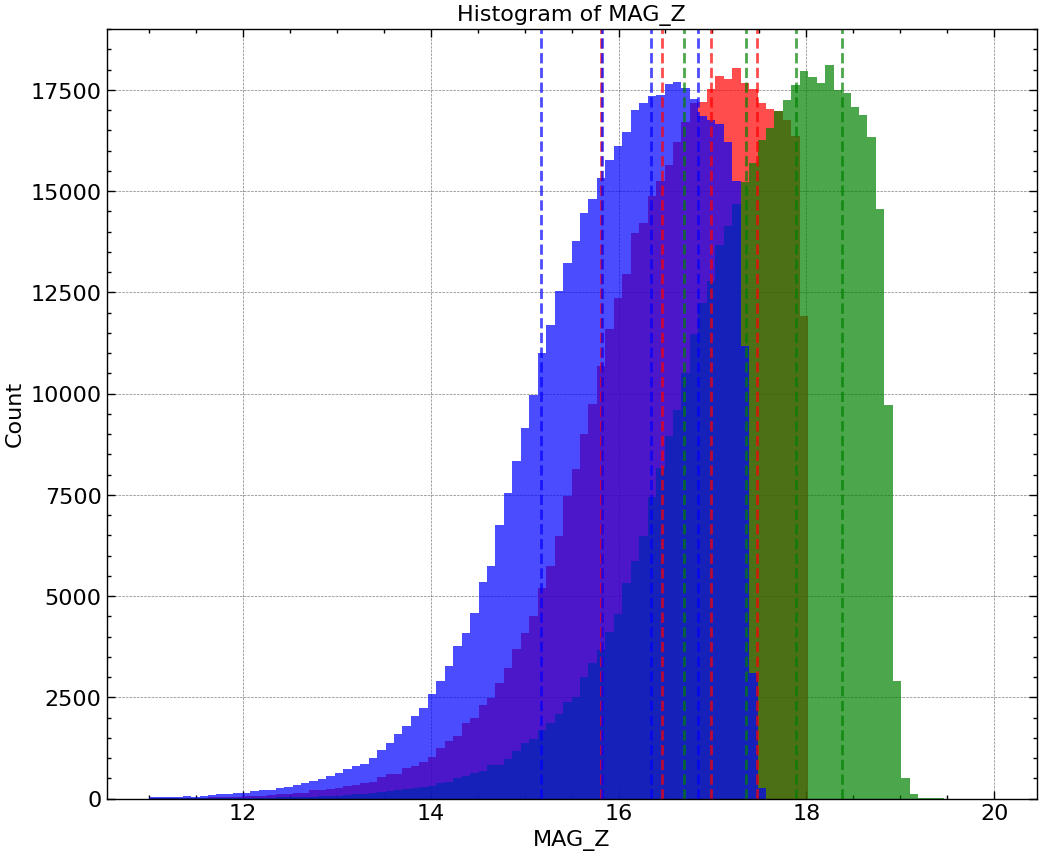

In [82]:
properties = ['MAG_R','MAG_G','MAG_Z']
bins = 5
colors= {'MAG_R': 'red', 'MAG_G': 'green', 'MAG_Z': 'blue'}
edges_prop = {}
for part in [ 'full']:
    plt.figure(figsize=(12, 10))
    edges_prop[part] = {}
    for property in properties:
        if part == 'full':
            data = table[property]
        elif part == 'north' :
            data = table_north[property]
        else:            
            data = table_south[property]
    
        edges = np.quantile(data, np.linspace(0, 1, bins + 1))
        edges_prop[part][property] = edges
        plt.hist(data, bins=100, alpha=0.7,range=(11,20), color=colors[property])
        for edge in range(len(edges)-2):
            plt.axvline(edges[edge+1], color=colors[property], linestyle='--', alpha=0.7)
    plt.xlabel(property)
    plt.ylabel('Count')
    plt.title(f'Histogram of {property}')
    plt.show()

In [83]:
print("MAG_R bins:")
BIN_COL = ['MAG_R','MAG_G','MAG_Z']
bins_list = {}
_bin_masks  = {}

_bin_tables = {}

for part in ['full']:
    bins_list[part] = {}
    for BIN in BIN_COL:
    #print(f"  {part}: {edges_prop[part][BIN_COL]}")
        bins_to_run = make_bins_full(
            table, RA_all, DEC_all,
            col     = BIN,
            edges   = edges_prop[part][BIN],
            weights = None, mask_store=_bin_masks, table_store=_bin_tables
        )
        bins_list[part][BIN] = bins_to_run


MAG_R bins:
  MAG_R [8.48, 15.8): 96,647 galaxies
  MAG_R [15.8, 16.5): 96,646 galaxies
  MAG_R [16.5, 17): 96,646 galaxies
  MAG_R [17, 17.5): 96,645 galaxies
  MAG_R [17.5, 18): 96,647 galaxies
  MAG_G [9.25, 16.7): 96,647 galaxies
  MAG_G [16.7, 17.4): 96,646 galaxies
  MAG_G [17.4, 17.9): 96,646 galaxies
  MAG_G [17.9, 18.4): 96,646 galaxies
  MAG_G [18.4, 21.7): 96,646 galaxies
  MAG_Z [7.85, 15.2): 96,647 galaxies
  MAG_Z [15.2, 15.8): 96,646 galaxies
  MAG_Z [15.8, 16.4): 96,646 galaxies
  MAG_Z [16.4, 16.8): 96,646 galaxies
  MAG_Z [16.8, 17.6): 96,646 galaxies


In [115]:
# # Optional: visualise the bin-property distribution
# fig, ax = plt.subplots(figsize=(6, 3))
# if callable(BIN_COL):
#     values_plot = BIN_COL(table)
#     xlabel = "Derived bin property"
# else:
#     values_plot = np.asarray(table[BIN_COL], dtype=float)
#     xlabel = BIN_COL

# ax.hist(values_plot, bins=80, color='steelblue', alpha=0.7)
# for _, edges_i in zip(range(len(bins_to_run) + 1),
#                       [list(bin_masks.keys())[0].split('[')[1].split(',')[0]] +
#                       [k.split('[')[1].split(',')[1].rstrip(')') for k in bin_masks]):
#     pass  # edges drawn below via vlines
# # Draw bin edges from the label strings
# edge_vals = []
# for lbl in bin_masks:
#     lo = float(lbl.split('[')[1].split(',')[0])
#     hi = float(lbl.split(',')[1].rstrip(')').strip())
#     edge_vals.extend([lo, hi])
# edge_vals = sorted(set(edge_vals))
# for ev in edge_vals:
#     ax.axvline(ev, color='tomato', lw=1.2, ls='--')

# ax.set_xlabel(xlabel)
# ax.set_ylabel('Count')
# ax.set_title('Bin property distribution')
# plt.tight_layout()
# plt.show()


In [141]:
matched_dr=Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/DR_matched.fits')[1].read())

from scipy.stats import gaussian_kde
kde = gaussian_kde(matched_dr['Z'],bw_method=0.25)
samples = kde.resample(2400).flatten()
samples = np.clip(samples, 0, None)
y_samples=kde.evaluate(samples)
samples_sorted=np.sort(samples)
arg=np.argsort(samples)
y_samples_sorted= y_samples[arg]


z=samples_sorted
n_z=y_samples_sorted
n_z /= np.trapz(y_samples_sorted, samples_sorted)
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u
dL = cosmo.comoving_distance(samples_sorted).to(u.Mpc).value
num  = np.trapz(dL*n_z**2, z)
denom  = np.trapz(n_z**2, z)
chi_eff = num/denom
def theta_to_r(theta_deg):
    return chi_eff * np.deg2rad(theta_deg)

def r_to_theta(r_mpc):
    return np.rad2deg(r_mpc / chi_eff)


zeff = np.trapz(z*n_z, z) /np.trapz(n_z, z)
print('zeff = ', zeff)
dc_zeff= cosmo.comoving_distance(zeff).to(u.Mpc).value
dc_zeff

def theta_to_r_dc(theta_deg):
    return dc_zeff * np.deg2rad(theta_deg)
def r_to_theta_dc(r_mpc):
    return np.rad2deg(r_mpc / dc_zeff)

zeff =  0.09147099142184158


In [143]:
import pyccl as ccl

cosmo_hmcode = ccl.Cosmology(
    Omega_c=0.264,  # Cold dark matter density
    Omega_b=0.049,  # Baryon density
    h=0.674,        # Hubble parameter
    sigma8=0.811,    # Power spectrum normalization
    n_s=0.965       # Spectral index,
    ,matter_power_spectrum="camb",
    
    extra_parameters={
        "camb": {
            "halofit_version": "mead2020",

        }
    }

)

cosmo_halofit = ccl.Cosmology(
    Omega_c=0.264,  # Cold dark matter density
    Omega_b=0.049,  # Baryon density
    h=0.674,        # Hubble parameter
    sigma8=0.811,    # Power spectrum normalization
    n_s=0.965       # Spectral index
)


theta = np.logspace(np.log10(1e-2), np.log10(15), 40) # degrees


bias = np.ones_like(z) * 1
ell = np.arange(2, 2000)
tr_hm = ccl.NumberCountsTracer(cosmo_hmcode, dndz=(z, n_z), bias=(z, bias),has_rsd=False)
cl_hm = ccl.angular_cl(cosmo_hmcode, tr_hm, tr_hm, ell)
wtheta_hm = ccl.correlation(theta = theta, ell = ell, C_ell = cl_hm, cosmo = cosmo_hmcode)


In [144]:
def w_theta_func(theta,a):
    bias = a*np.ones_like(z) #+ 0.5*z
    tr_hm = ccl.NumberCountsTracer(cosmo_hmcode, dndz=(z, n_z), bias=(z, bias),has_rsd=False)
    cl_hm = ccl.angular_cl(cosmo_hmcode, tr_hm, tr_hm, ell)
    wtheta_hm = ccl.correlation(theta = theta, ell = ell, C_ell = cl_hm, cosmo = cosmo_hmcode)
    return wtheta_hm

def w_theta_func_halofit(theta,a):
    bias = a*np.ones_like(z) #+ 0.5*z
    tr = ccl.NumberCountsTracer(cosmo_halofit, dndz=(z, n_z), bias=(z, bias),has_rsd=False)
    cl = ccl.angular_cl(cosmo_halofit, tr, tr, ell)
    wtheta = ccl.correlation(theta = theta, ell = ell, C_ell = cl, cosmo = cosmo_halofit)
    return wtheta

In [84]:
results_dict = {}
for part in ['full']:
    results_dict[part] = {}
    
    for BIN in BIN_COL:
        res = run_all_bins(bins_list[part][BIN], parallel=True)
        results_dict[part][BIN] = {lbl: res[lbl] for lbl, *_ in bins_list[part][BIN] if lbl in res}

# results = run_all_bins(bins_to_run, parallel=True)

# # Keep insertion order matching original bin order
# results = {lbl: results[lbl] for lbl, *_ in bins_to_run if lbl in results}


Running 5 bins  [ERROR=jackknife, weights=True]
  [MAG_R [17, 17.5)]  N=96,645  7.2s
  [MAG_R [16.5, 17)]  N=96,646  7.5s
  [MAG_R [17.5, 18)]  N=96,647  7.6s
  [MAG_R [8.48, 15.8)]  N=96,647  7.6s
  [MAG_R [15.8, 16.5)]  N=96,646  7.6s
All bins done in 7.7s total
Running 5 bins  [ERROR=jackknife, weights=True]
  [MAG_G [17.4, 17.9)]  N=96,646  7.3s
  [MAG_G [18.4, 21.7)]  N=96,646  7.7s
  [MAG_G [17.9, 18.4)]  N=96,646  7.7s
  [MAG_G [16.7, 17.4)]  N=96,646  7.7s
  [MAG_G [9.25, 16.7)]  N=96,647  7.7s
All bins done in 7.7s total
Running 5 bins  [ERROR=jackknife, weights=True]
  [MAG_Z [15.8, 16.4)]  N=96,646  7.8s
  [MAG_Z [15.2, 15.8)]  N=96,646  7.8s
  [MAG_Z [7.85, 15.2)]  N=96,647  7.9s
  [MAG_Z [16.8, 17.6)]  N=96,646  7.9s
  [MAG_Z [16.4, 16.8)]  N=96,646  7.9s
All bins done in 7.9s total


In [85]:
for result in results_dict['full']:
    for bin in results_dict['full'][result]:
        print(f"{bin}: N={results_dict['full'][result][bin]['n']:,}  xi[0]={results_dict['full'][result][bin]['xi'][0]:.4f} ± {results_dict['full'][result][bin]['sig'][0]:.4f}")

MAG_R [8.48, 15.8): N=96,647  xi[0]=7.9263 ± 0.6319
MAG_R [15.8, 16.5): N=96,646  xi[0]=5.2388 ± 0.4681
MAG_R [16.5, 17): N=96,646  xi[0]=4.0887 ± 0.4623
MAG_R [17, 17.5): N=96,645  xi[0]=3.6111 ± 0.4749
MAG_R [17.5, 18): N=96,647  xi[0]=4.4623 ± 0.4813
MAG_G [9.25, 16.7): N=96,647  xi[0]=7.6940 ± 0.5848
MAG_G [16.7, 17.4): N=96,646  xi[0]=4.7715 ± 0.3314
MAG_G [17.4, 17.9): N=96,646  xi[0]=4.2925 ± 0.4529
MAG_G [17.9, 18.4): N=96,646  xi[0]=4.1336 ± 0.5531
MAG_G [18.4, 21.7): N=96,646  xi[0]=5.0004 ± 0.4752
MAG_Z [7.85, 15.2): N=96,647  xi[0]=8.0264 ± 0.6596
MAG_Z [15.2, 15.8): N=96,646  xi[0]=5.3390 ± 0.4614
MAG_Z [15.8, 16.4): N=96,646  xi[0]=4.1577 ± 0.4483
MAG_Z [16.4, 16.8): N=96,646  xi[0]=3.6738 ± 0.4772
MAG_Z [16.8, 17.6): N=96,646  xi[0]=4.5621 ± 0.4831


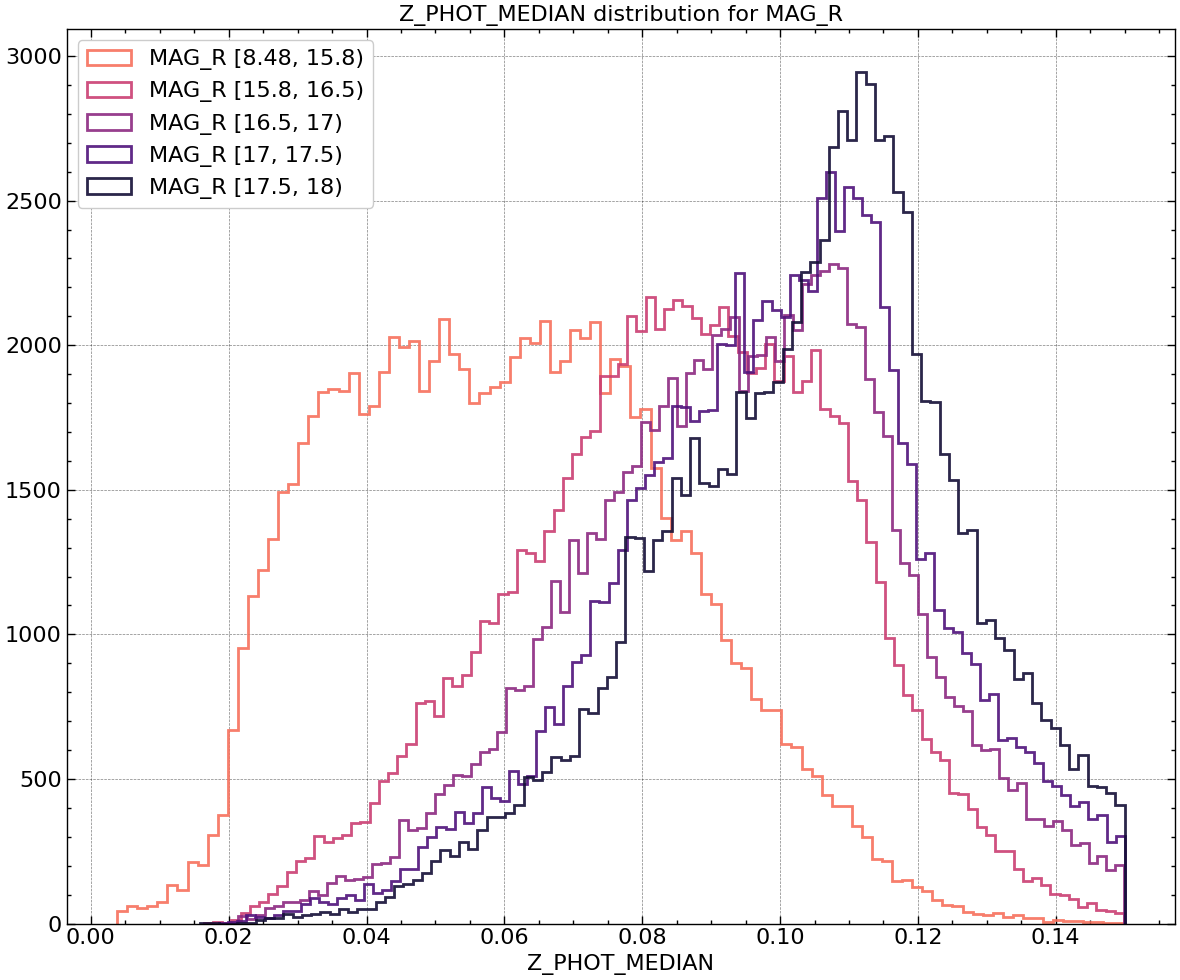

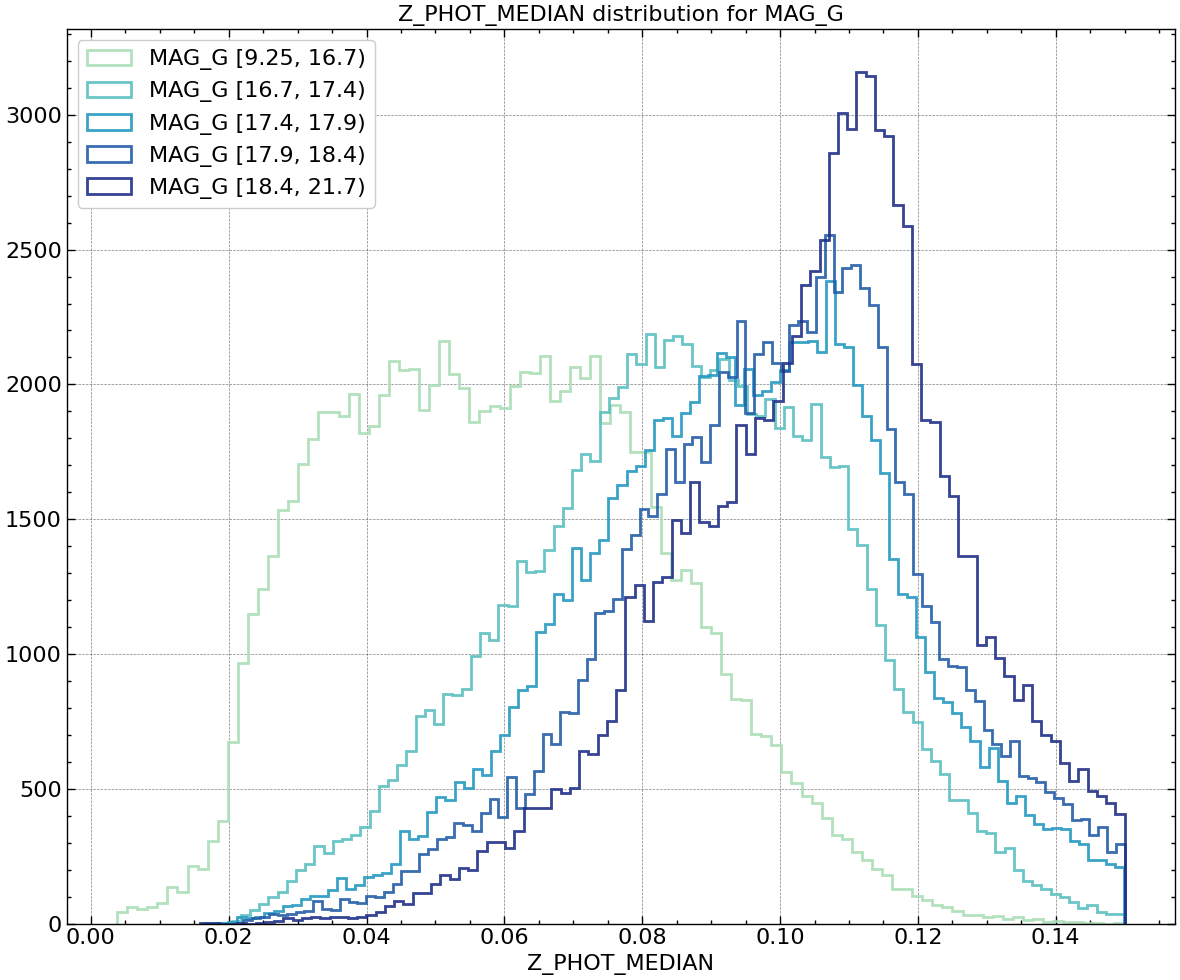

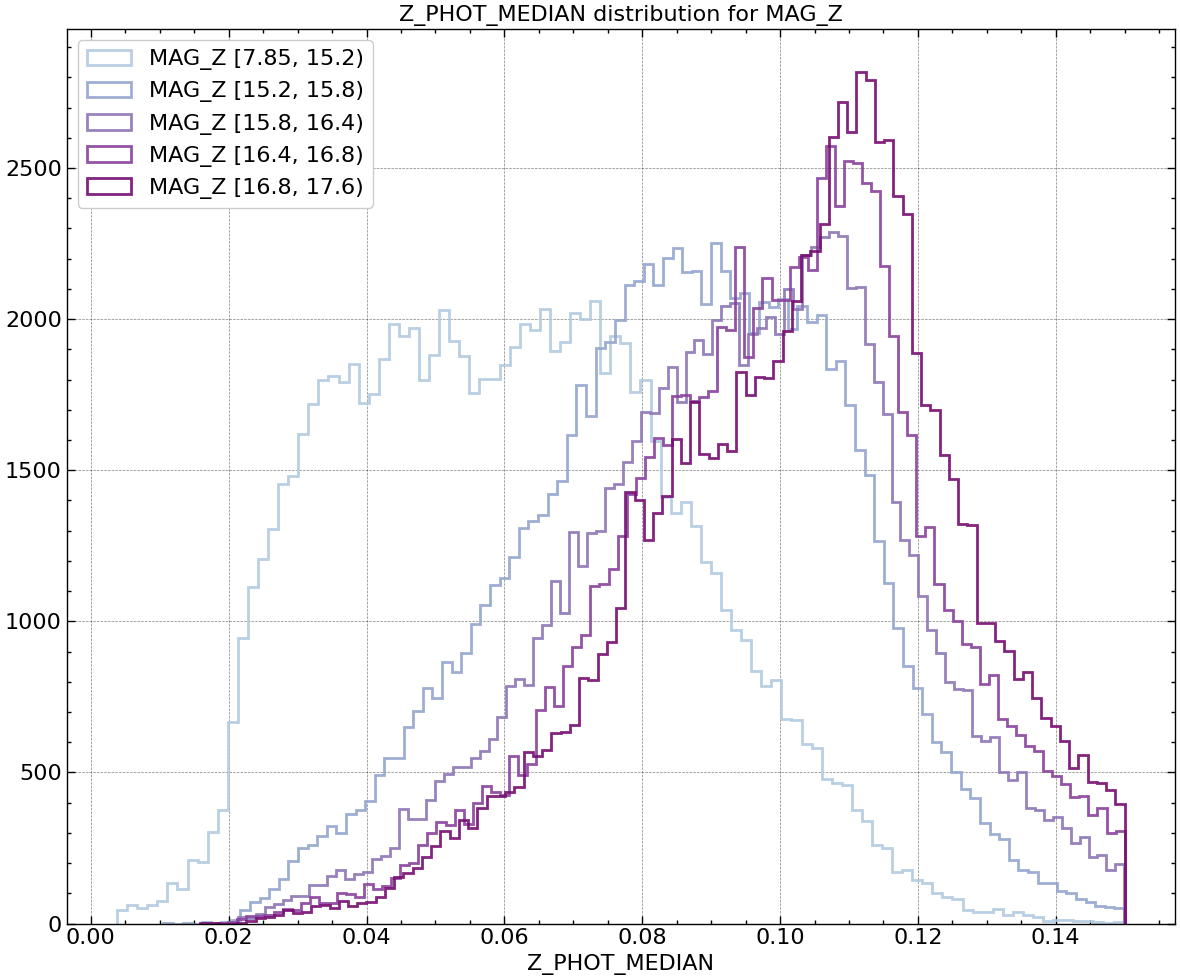

In [86]:
prop_colors = {
    'MAG_R':  plt.cm.magma_r(np.linspace(0.3, 0.9, 5))
,
    'MAG_G': plt.cm.YlGnBu(np.linspace(0.3, 0.9, 5)),
    'MAG_Z': plt.cm.BuPu(np.linspace(0.3, 0.9, 5)),
}

for prop, color in prop_colors.items():
    plt.figure(figsize=(12, 10))
    i =0 
    for key_i, mask in _bin_masks.items():
        if prop in key_i:
            z = table[mask]['Z_PHOT_MEDIAN']
            z = z[z > 0]
            
            plt.hist(z, bins=100, color=color[i], alpha=0.9, label=key_i,histtype='step',lw = 2)
            i+=1

    plt.xlabel('Z_PHOT_MEDIAN')
    plt.title(f'Z_PHOT_MEDIAN distribution for {prop}')
    plt.legend()
    plt.tight_layout()
    plt.show()


MAG_R [8.48, 15.8): N=96,647
MAG_R [15.8, 16.5): N=96,646
MAG_R [16.5, 17): N=96,646
MAG_R [17, 17.5): N=96,645
MAG_R [17.5, 18): N=96,647


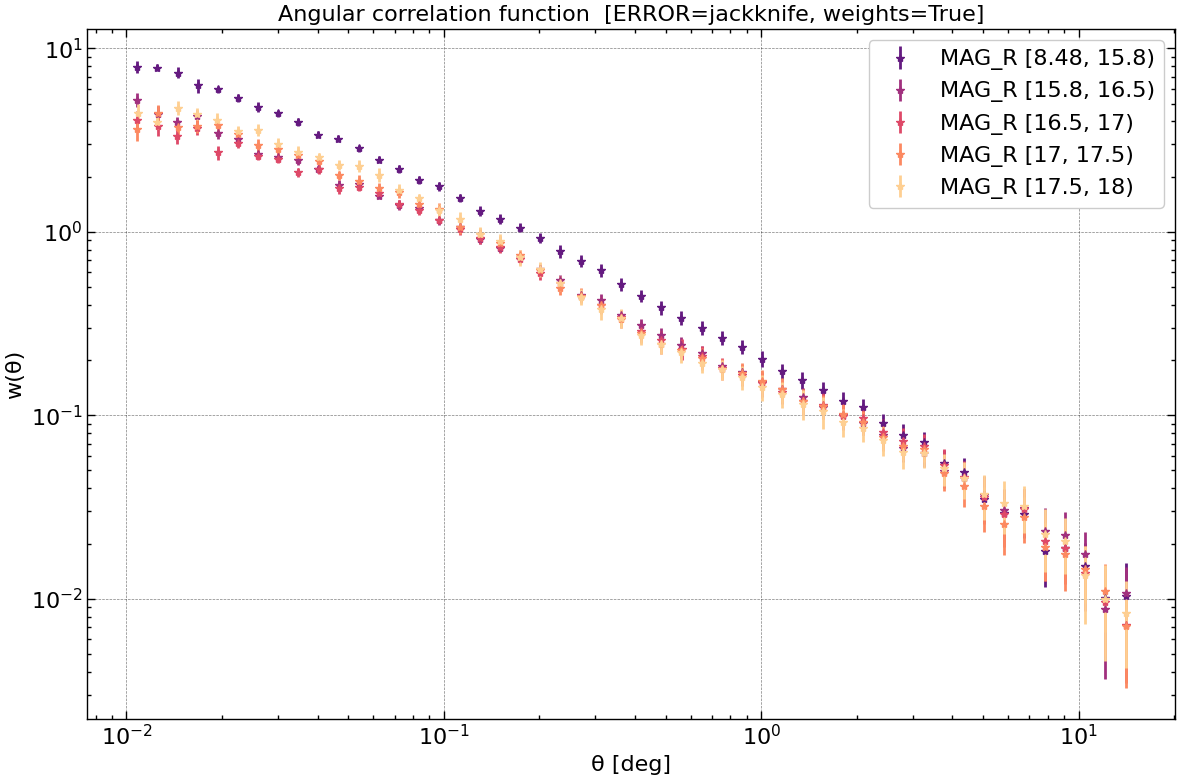

MAG_G [9.25, 16.7): N=96,647
MAG_G [16.7, 17.4): N=96,646
MAG_G [17.4, 17.9): N=96,646
MAG_G [17.9, 18.4): N=96,646
MAG_G [18.4, 21.7): N=96,646


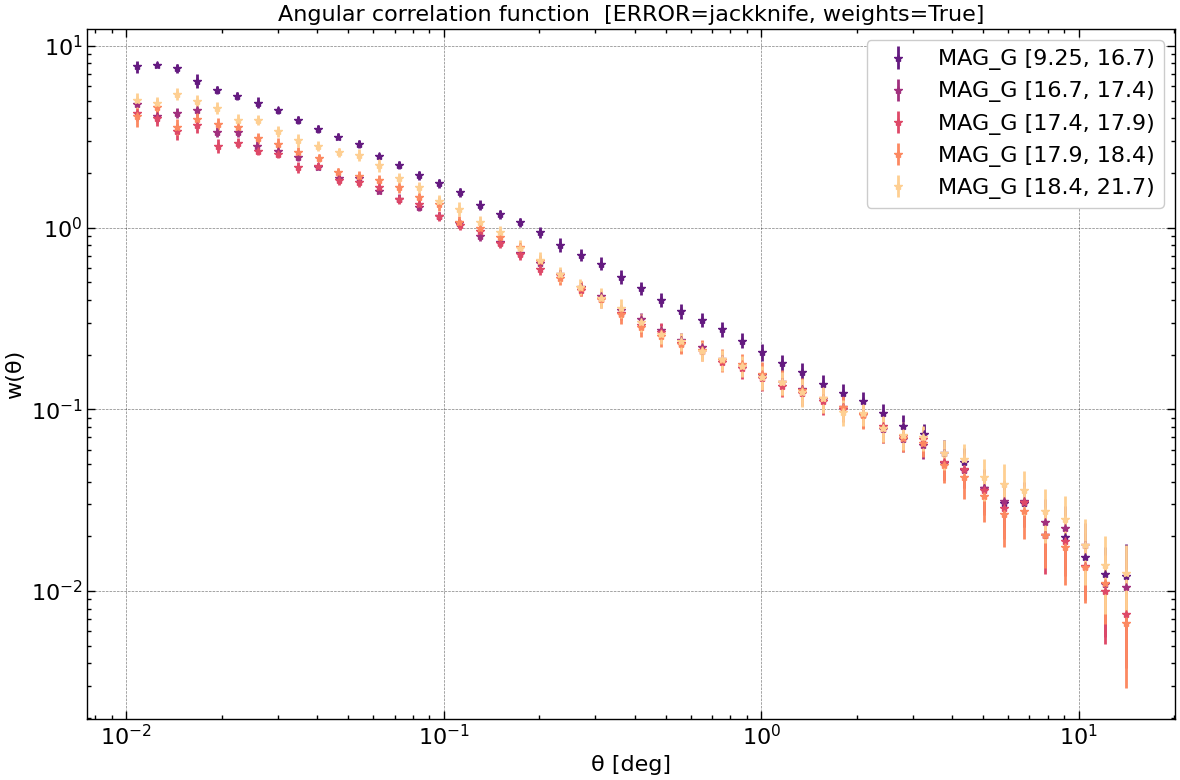

MAG_Z [7.85, 15.2): N=96,647
MAG_Z [15.2, 15.8): N=96,646
MAG_Z [15.8, 16.4): N=96,646
MAG_Z [16.4, 16.8): N=96,646
MAG_Z [16.8, 17.6): N=96,646


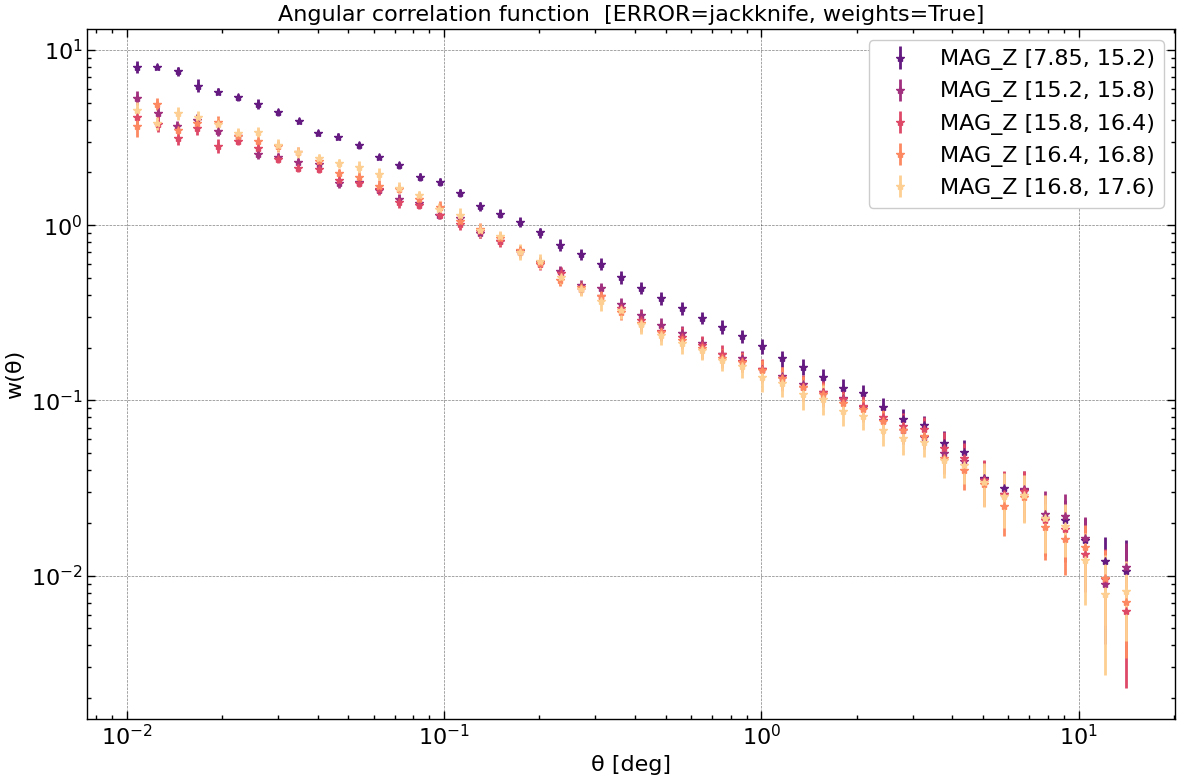

In [87]:
colors = plt.cm.magma(np.linspace(0.3, 0.9, len(results_dict['full'][result])))
for result in results_dict['full']:
    plt.figure(figsize=(12, 8))
    for bin_label in results_dict['full'][result]:
        print(f"{bin_label}: N={results_dict['full'][result][bin_label]['n']:,}")
        plt.errorbar(results_dict['full'][result][bin_label]['meanr'], 
                     results_dict['full'][result][bin_label]['xi'], 
                     yerr=results_dict['full'][result][bin_label]['sig'],
                     fmt='*-', label=bin_label, ls='None', color=colors[list(results_dict['full'][result]).index(bin_label)])

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('θ [deg]')
    plt.ylabel('w(θ)')
    plt.title(f"Angular correlation function  [ERROR={ERROR}, weights={USE_WEIGHTS}]")
    plt.legend()
    plt.tight_layout()
    plt.show()


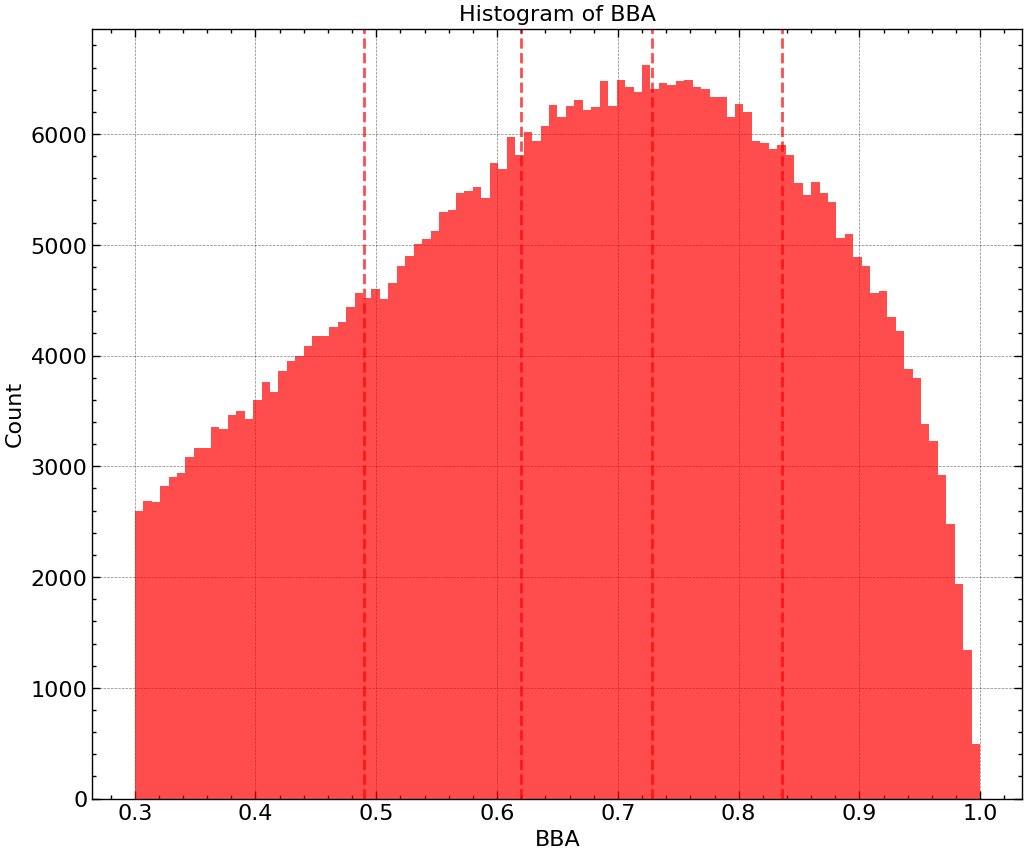

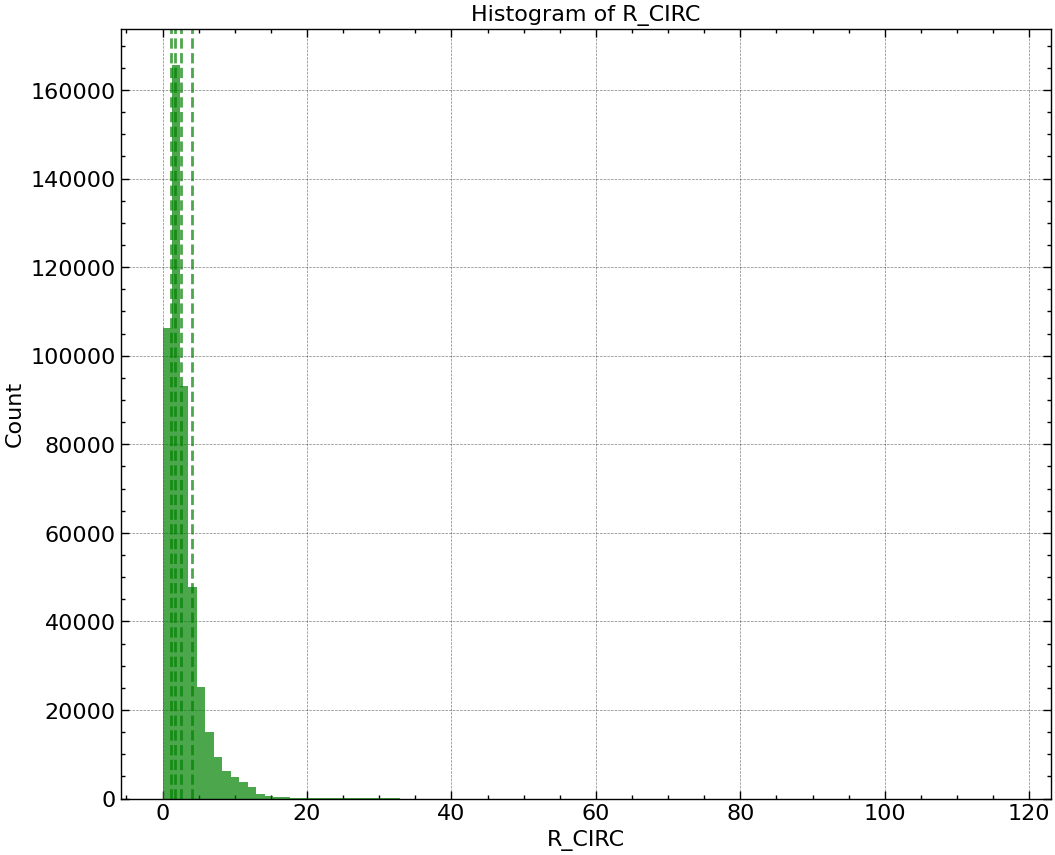

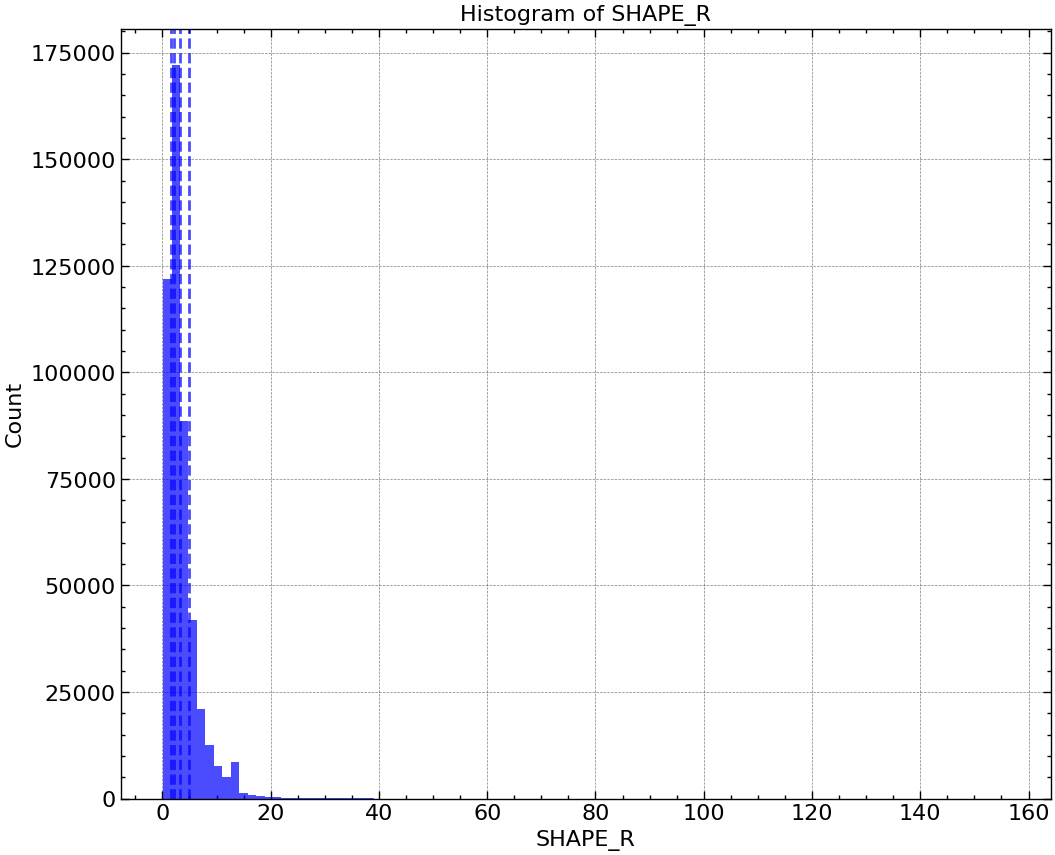

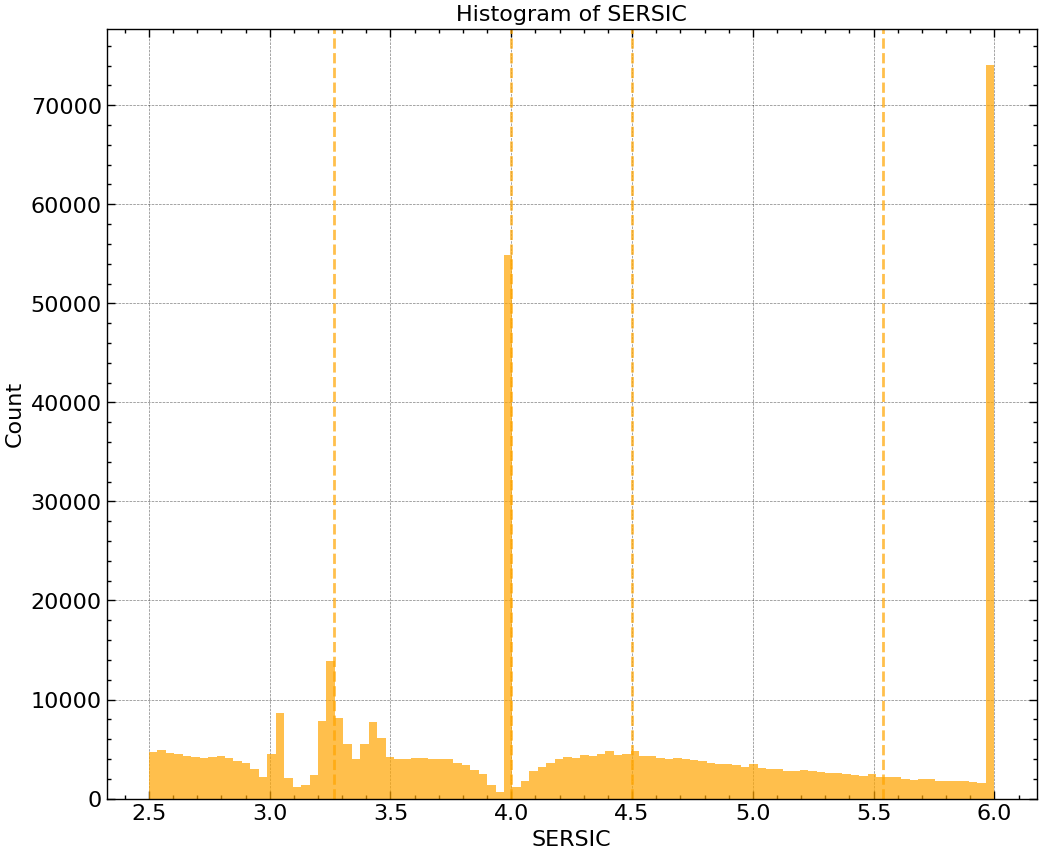

In [93]:
properties = ['BBA','R_CIRC', 'SHAPE_R','SERSIC']
bins = 5
colors= {'BBA': 'red', 'R_CIRC': 'green', 'SHAPE_R': 'blue', 'SERSIC': 'orange'}
edges_prop = {}
for part in [ 'full']:
    
    edges_prop[part] = {}
    for property in properties:
        plt.figure(figsize=(12, 10))
        if part == 'full':
            data = table[property]
        elif part == 'north' :
            data = table_north[property]
        else:            
            data = table_south[property]
    
        edges = np.quantile(data, np.linspace(0, 1, bins + 1))
        edges_prop[part][property] = edges
        plt.hist(data, bins=100, alpha=0.7, color=colors[property])
        for edge in range(len(edges)-2):
            plt.axvline(edges[edge+1], color=colors[property], linestyle='--', alpha=0.7)
        plt.xlabel(property)
        plt.ylabel('Count')
        plt.title(f'Histogram of {property}')
        plt.show()

In [98]:
print("MAG_R bins:")
BIN_COL = ['BBA','R_CIRC', 'SHAPE_R','SERSIC']
bins_list = {}
_bin_masks  = {}
_bin_tables = {}
for part in ['full']:
    bins_list[part] = {}
    for BIN in BIN_COL:
    #print(f"  {part}: {edges_prop[part][BIN_COL]}")
        bins_to_run = make_bins_full(
            table, RA_all, DEC_all,
            col     = BIN,
            edges   = edges_prop[part][BIN],
            weights = None,mask_store=_bin_masks, table_store=_bin_tables
        )
        bins_list[part][BIN] = bins_to_run


MAG_R bins:
  BBA [0.3, 0.49): 96,647 galaxies
  BBA [0.49, 0.62): 96,646 galaxies
  BBA [0.62, 0.728): 96,646 galaxies
  BBA [0.728, 0.836): 96,646 galaxies
  BBA [0.836, 1): 96,646 galaxies
  R_CIRC [0.0684, 1.18): 96,647 galaxies
  R_CIRC [1.18, 1.77): 96,646 galaxies
  R_CIRC [1.77, 2.59): 96,646 galaxies
  R_CIRC [2.59, 4.01): 96,646 galaxies
  R_CIRC [4.01, 117): 96,646 galaxies
  SHAPE_R [0.122, 1.51): 96,647 galaxies
  SHAPE_R [1.51, 2.22): 96,646 galaxies
  SHAPE_R [2.22, 3.19): 96,646 galaxies
  SHAPE_R [3.19, 4.92): 96,646 galaxies
  SHAPE_R [4.92, 156): 96,646 galaxies
  SERSIC [2.5, 3.27): 96,647 galaxies
  SERSIC [3.27, 4): 85,477 galaxies
  SERSIC [4, 4.5): 107,815 galaxies
  SERSIC [4.5, 5.54): 96,646 galaxies
  SERSIC [5.54, 6): 24,200 galaxies


In [95]:
#table["SERSIC"] >= bin_edges_sersic[l]

In [99]:
bin_edges_sersic = np.quantile(table['SERSIC'], np.linspace(0, 1, 5))

for l in range(len(bin_edges_sersic) - 1):
    print(f"Bin {l}: [{bin_edges_sersic[l]:.3f}, {bin_edges_sersic[l+1]:.3f})")
    print(f'Contains {np.sum((table["SERSIC"] >= bin_edges_sersic[l]) & (table["SERSIC"] < bin_edges_sersic[l+1]))}')

Bin 0: [2.500, 3.407)
Contains 120808
Bin 1: [3.407, 4.100)
Contains 120808
Bin 2: [4.100, 5.205)
Contains 120808
Bin 3: [5.205, 6.000)
Contains 48361


In [100]:
results_dict = {}
for part in ['full']:
    results_dict[part] = {}
    
    for BIN in BIN_COL:
        res = run_all_bins(bins_list[part][BIN], parallel=True)
        results_dict[part][BIN] = {lbl: res[lbl] for lbl, *_ in bins_list[part][BIN] if lbl in res}


Running 5 bins  [ERROR=jackknife, weights=True]
  [BBA [0.49, 0.62)]  N=96,646  7.7s
  [BBA [0.3, 0.49)]  N=96,647  7.8s
  [BBA [0.836, 1)]  N=96,646  7.8s
  [BBA [0.728, 0.836)]  N=96,646  7.8s
  [BBA [0.62, 0.728)]  N=96,646  7.8s
All bins done in 7.8s total
Running 5 bins  [ERROR=jackknife, weights=True]
  [R_CIRC [0.0684, 1.18)]  N=96,647  8.1s
  [R_CIRC [2.59, 4.01)]  N=96,646  8.1s
  [R_CIRC [1.77, 2.59)]  N=96,646  8.1s
  [R_CIRC [4.01, 117)]  N=96,646  8.1s
  [R_CIRC [1.18, 1.77)]  N=96,646  8.2s
All bins done in 8.2s total
Running 5 bins  [ERROR=jackknife, weights=True]
  [SHAPE_R [2.22, 3.19)]  N=96,646  7.8s
  [SHAPE_R [1.51, 2.22)]  N=96,646  7.8s
  [SHAPE_R [3.19, 4.92)]  N=96,646  7.9s
  [SHAPE_R [0.122, 1.51)]  N=96,647  7.9s
  [SHAPE_R [4.92, 156)]  N=96,646  7.9s
All bins done in 7.9s total
Running 5 bins  [ERROR=jackknife, weights=True]
  [SERSIC [4, 4.5)]  N=107,815  7.3s
  [SERSIC [5.54, 6)]  N=24,200  7.3s
  [SERSIC [3.27, 4)]  N=85,477  7.3s
  [SERSIC [2.5, 3.27)]

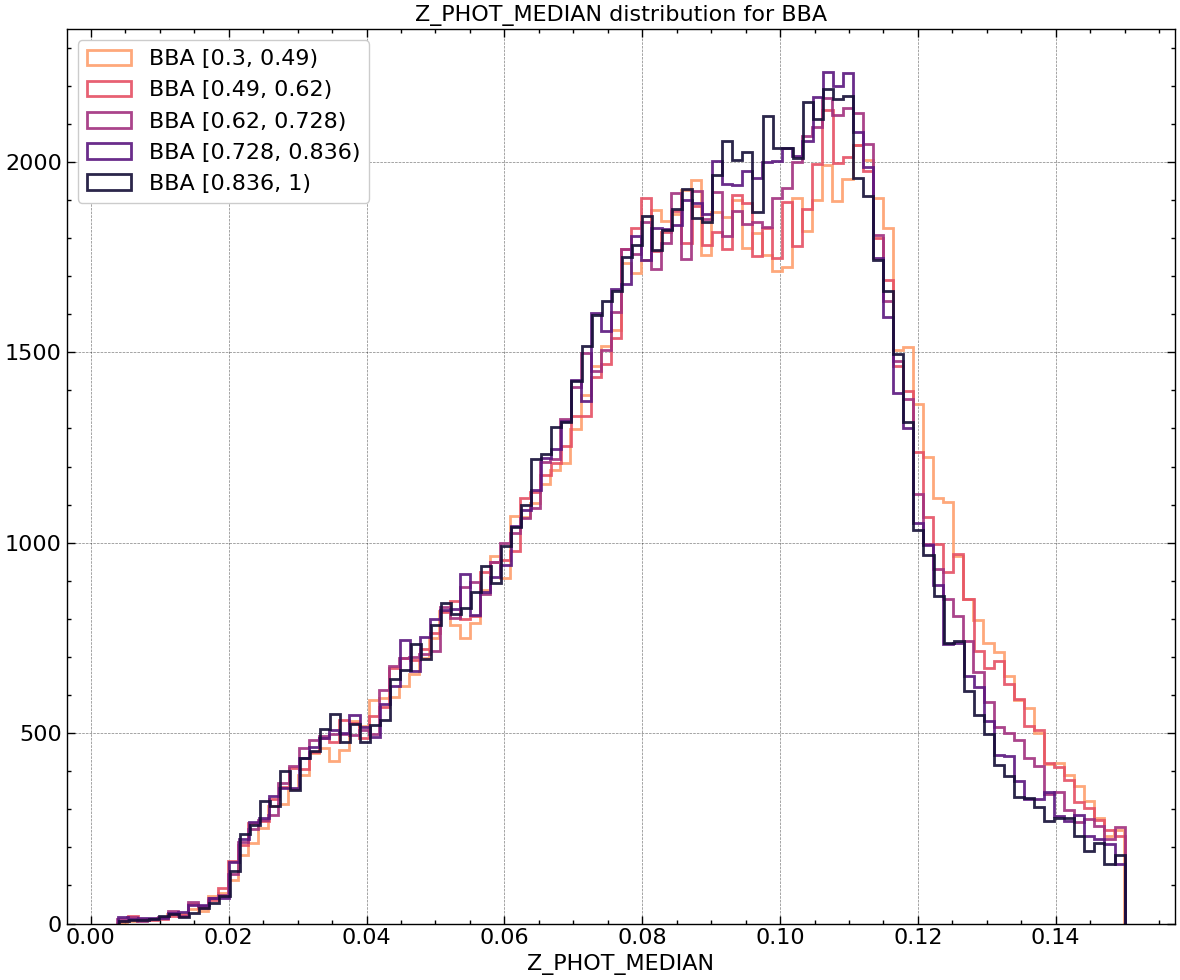

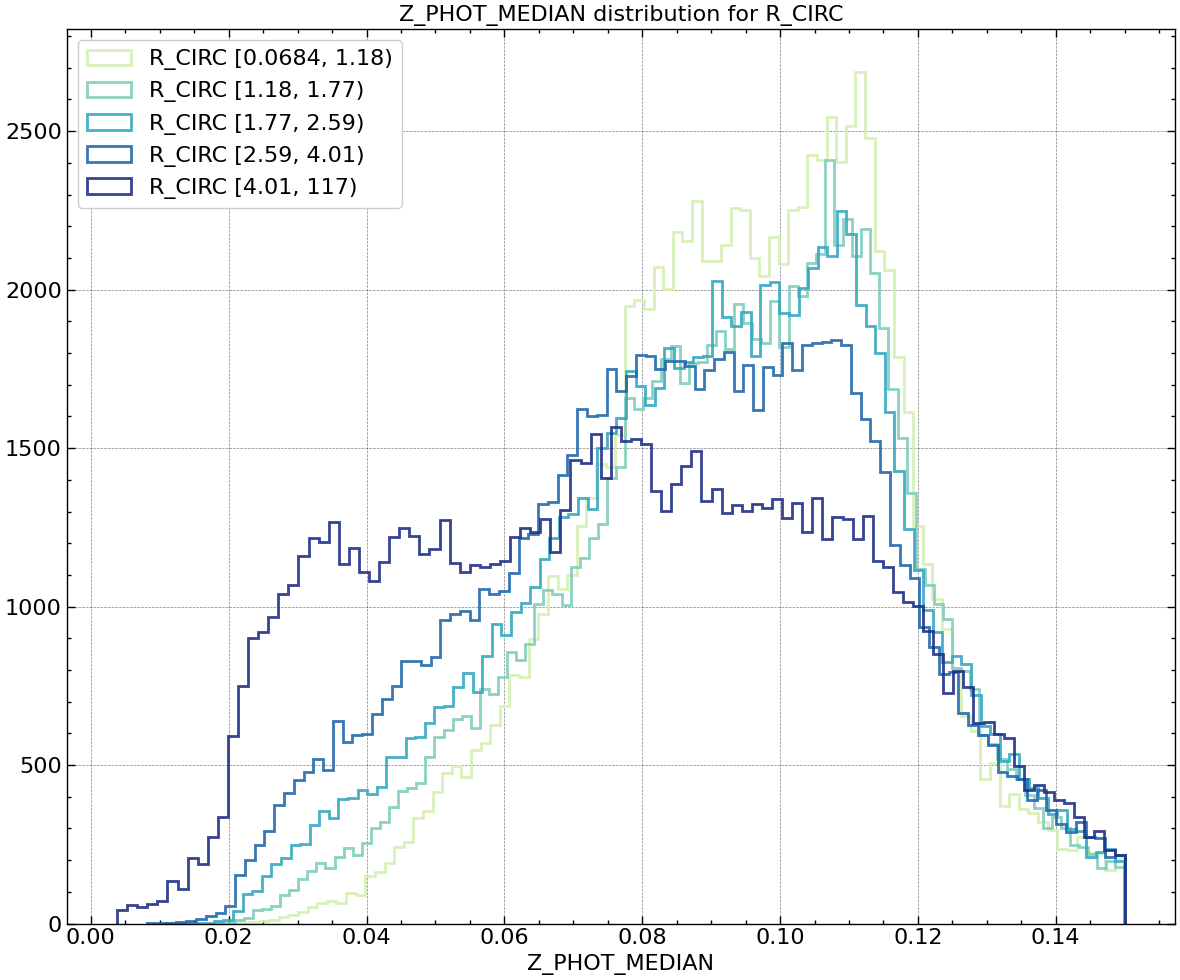

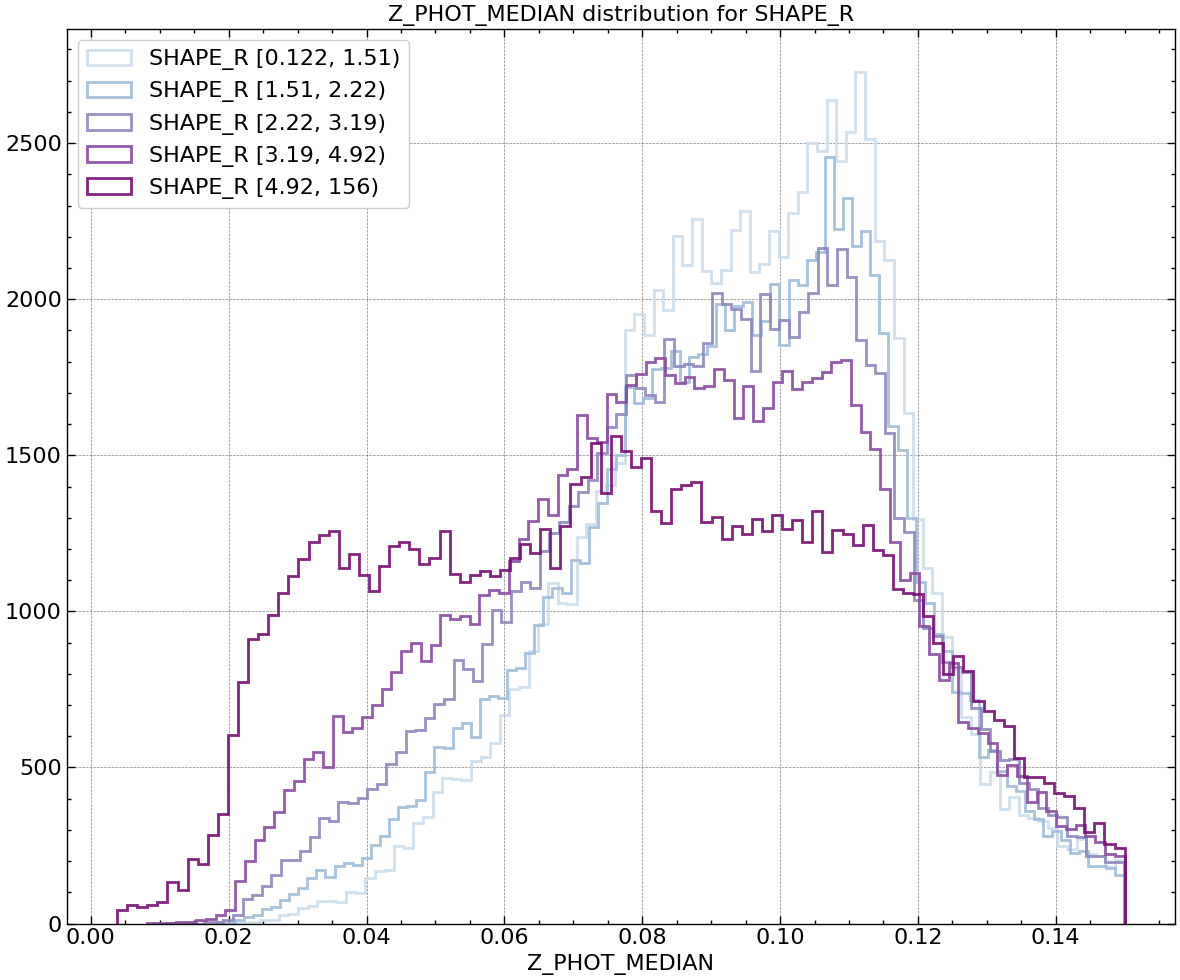

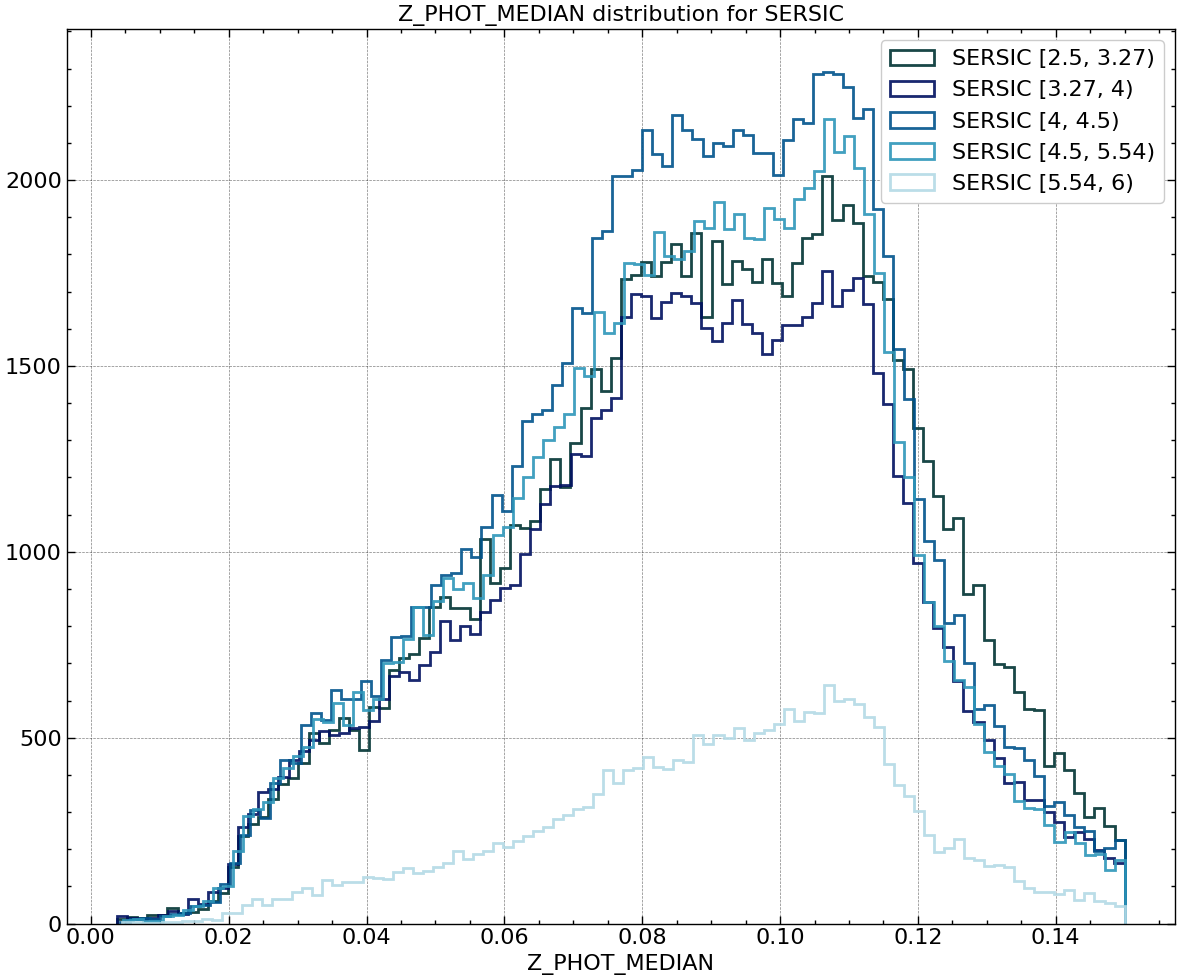

In [101]:
prop_colors = {
    'BBA':  plt.cm.magma_r(np.linspace(0.2, 0.9, 5)),
    'R_CIRC': plt.cm.YlGnBu(np.linspace(0.2, 0.9, 5)),
    'SHAPE_R': plt.cm.BuPu(np.linspace(0.2, 0.9, 5)),
    'SERSIC': plt.cm.ocean(np.linspace(0.2, 0.9, 5)),
}

for prop, color in prop_colors.items():
    plt.figure(figsize=(12, 10))
    i =0 
    for key_i, mask in _bin_masks.items():
        if prop in key_i:
            z = table[mask]['Z_PHOT_MEDIAN']
            z = z[z > 0]
            
            plt.hist(z, bins=100, color=color[i], alpha=0.9, label=key_i,histtype='step',lw = 2)
            i+=1

    plt.xlabel('Z_PHOT_MEDIAN')
    plt.title(f'Z_PHOT_MEDIAN distribution for {prop}')
    plt.legend()
    plt.tight_layout()
    plt.show()


BBA [0.3, 0.49): N=96,647
BBA [0.49, 0.62): N=96,646
BBA [0.62, 0.728): N=96,646
BBA [0.728, 0.836): N=96,646
BBA [0.836, 1): N=96,646


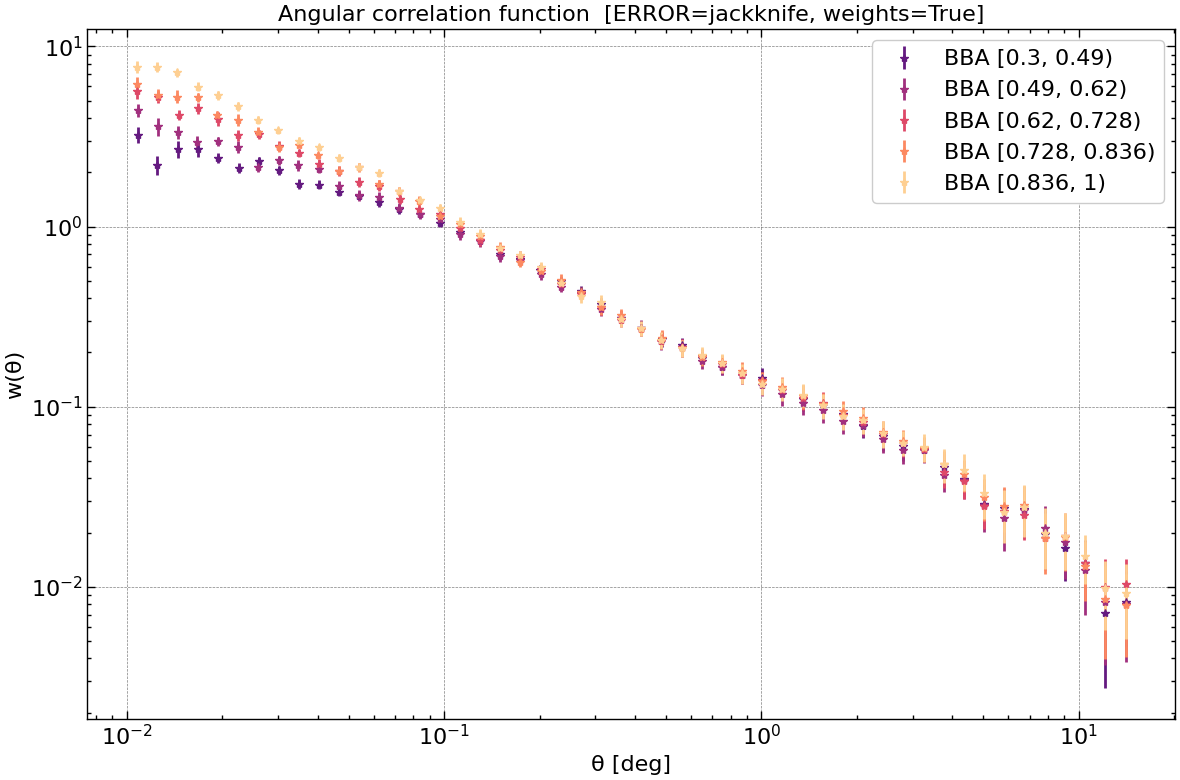

R_CIRC [0.0684, 1.18): N=96,647
R_CIRC [1.18, 1.77): N=96,646
R_CIRC [1.77, 2.59): N=96,646
R_CIRC [2.59, 4.01): N=96,646
R_CIRC [4.01, 117): N=96,646


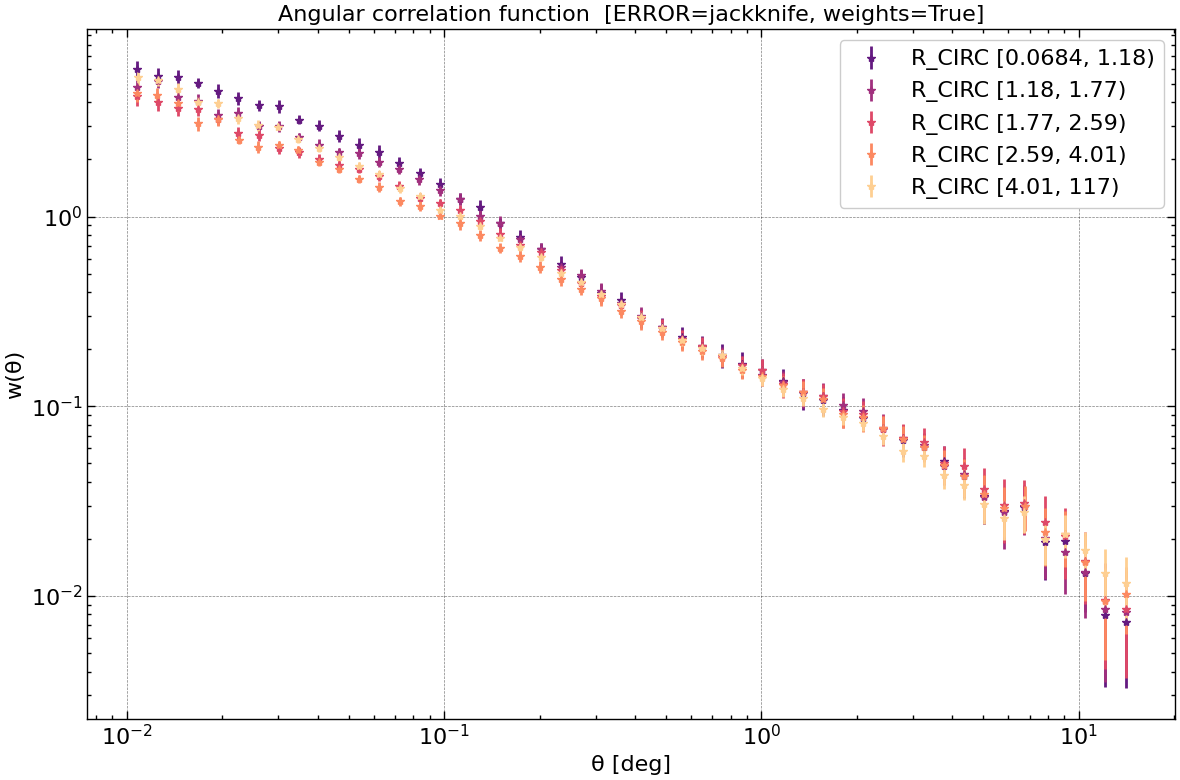

SHAPE_R [0.122, 1.51): N=96,647
SHAPE_R [1.51, 2.22): N=96,646
SHAPE_R [2.22, 3.19): N=96,646
SHAPE_R [3.19, 4.92): N=96,646
SHAPE_R [4.92, 156): N=96,646


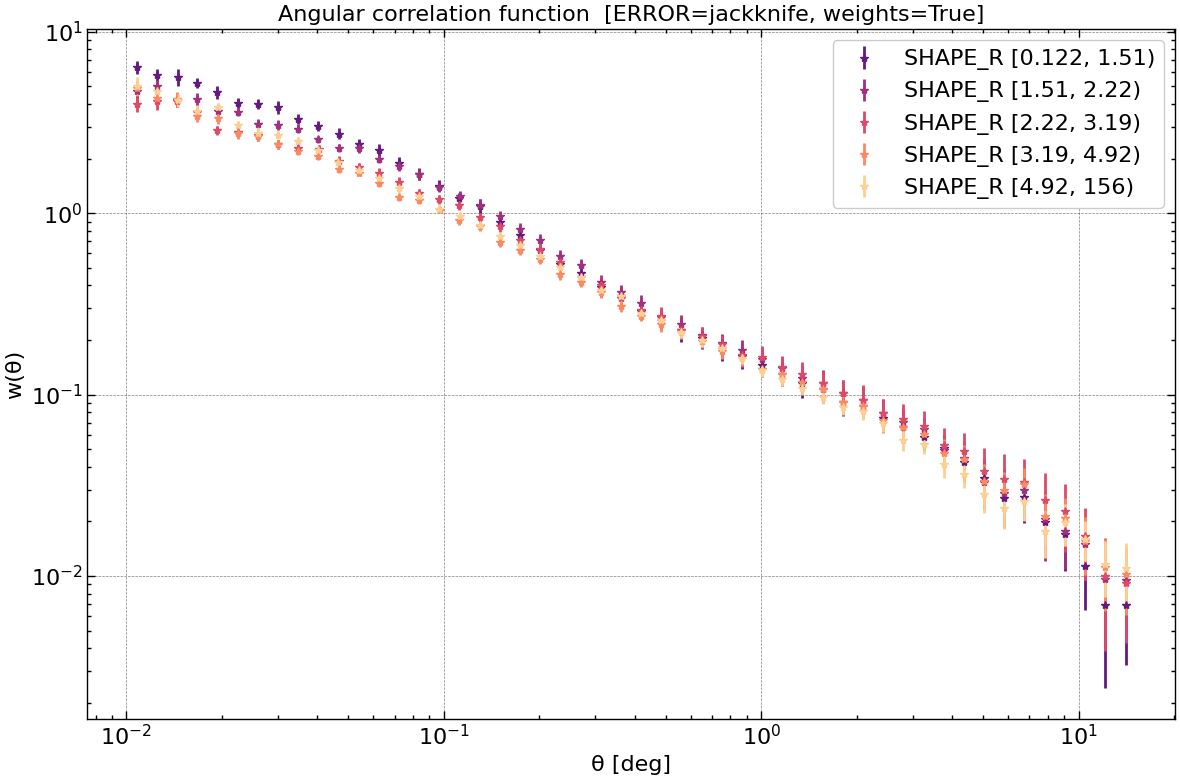

SERSIC [2.5, 3.27): N=96,647
SERSIC [3.27, 4): N=85,477
SERSIC [4, 4.5): N=107,815
SERSIC [4.5, 5.54): N=96,646
SERSIC [5.54, 6): N=24,200


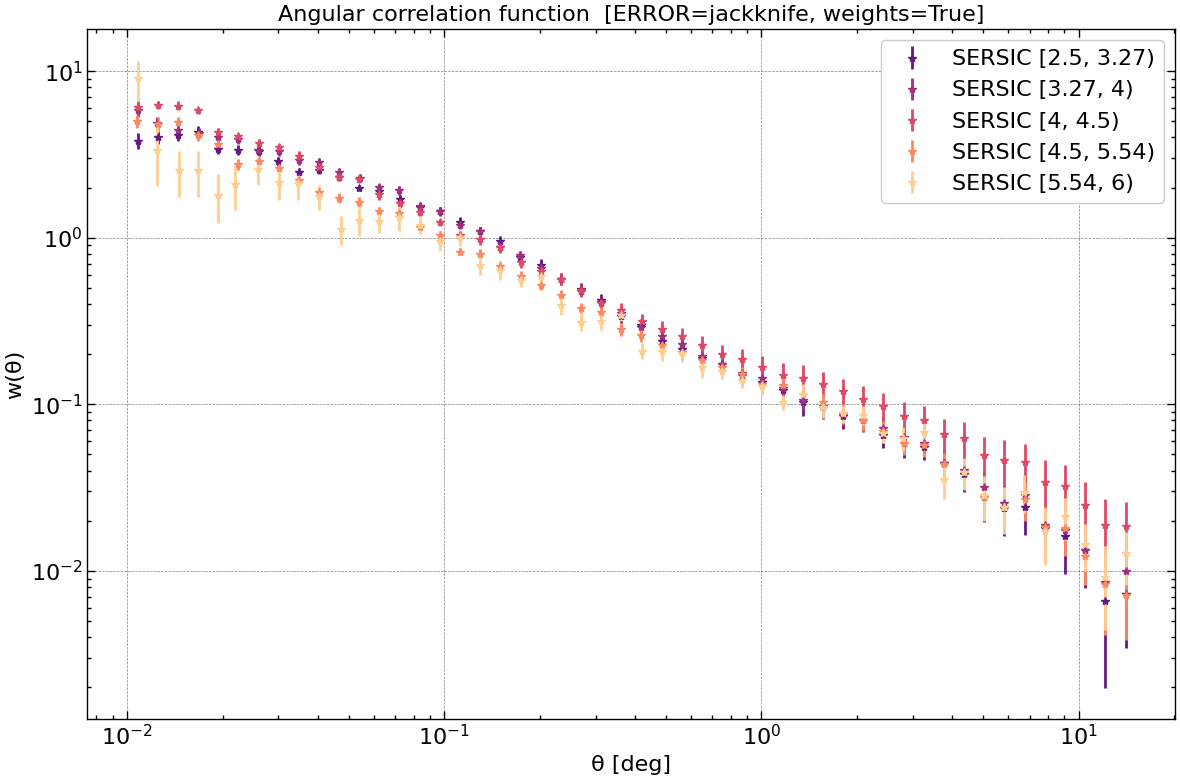

In [102]:
colors = plt.cm.magma(np.linspace(0.3, 0.9, len(results_dict['full']['BBA'])))
for result in results_dict['full']:
    plt.figure(figsize=(12, 8))
    for bin_label in results_dict['full'][result]:
        print(f"{bin_label}: N={results_dict['full'][result][bin_label]['n']:,}")
        plt.errorbar(results_dict['full'][result][bin_label]['meanr'], 
                     results_dict['full'][result][bin_label]['xi'], 
                     yerr=results_dict['full'][result][bin_label]['sig'],
                     fmt='*-', label=bin_label, ls='None', color=colors[list(results_dict['full'][result]).index(bin_label)])

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('θ [deg]')
    plt.ylabel('w(θ)')
    plt.title(f"Angular correlation function  [ERROR={ERROR}, weights={USE_WEIGHTS}]")
    plt.legend()
    plt.tight_layout()
    plt.show()

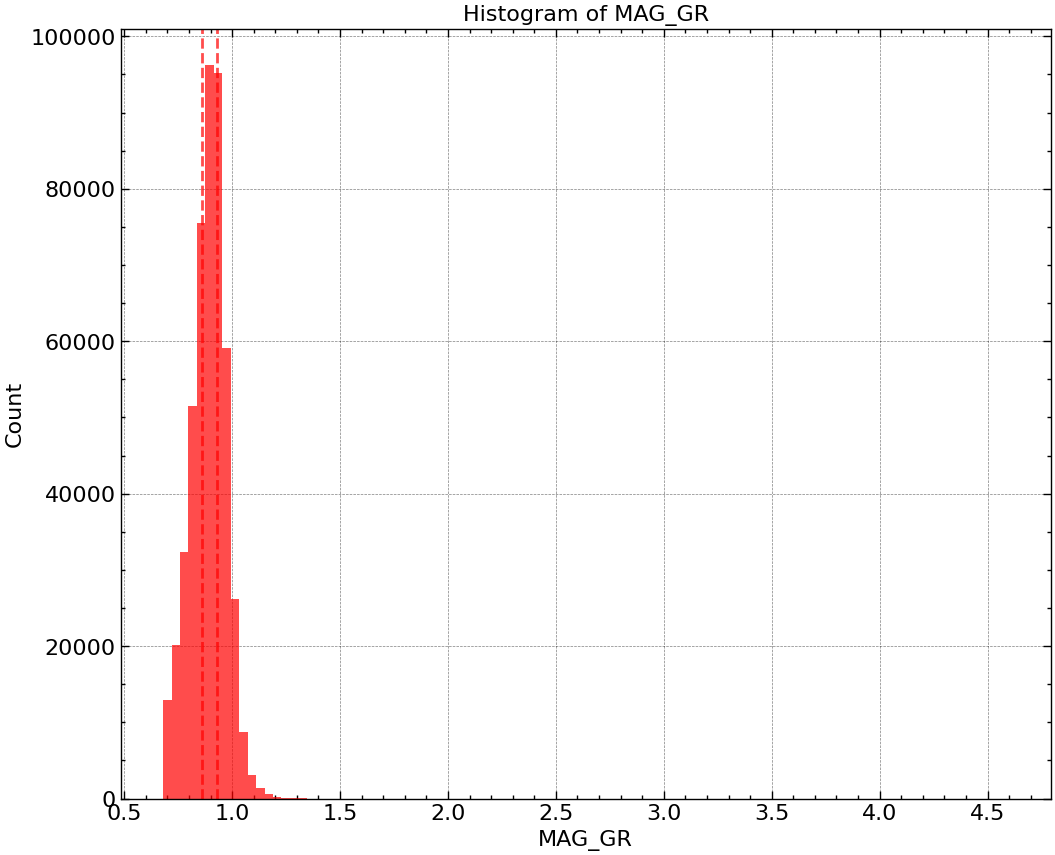

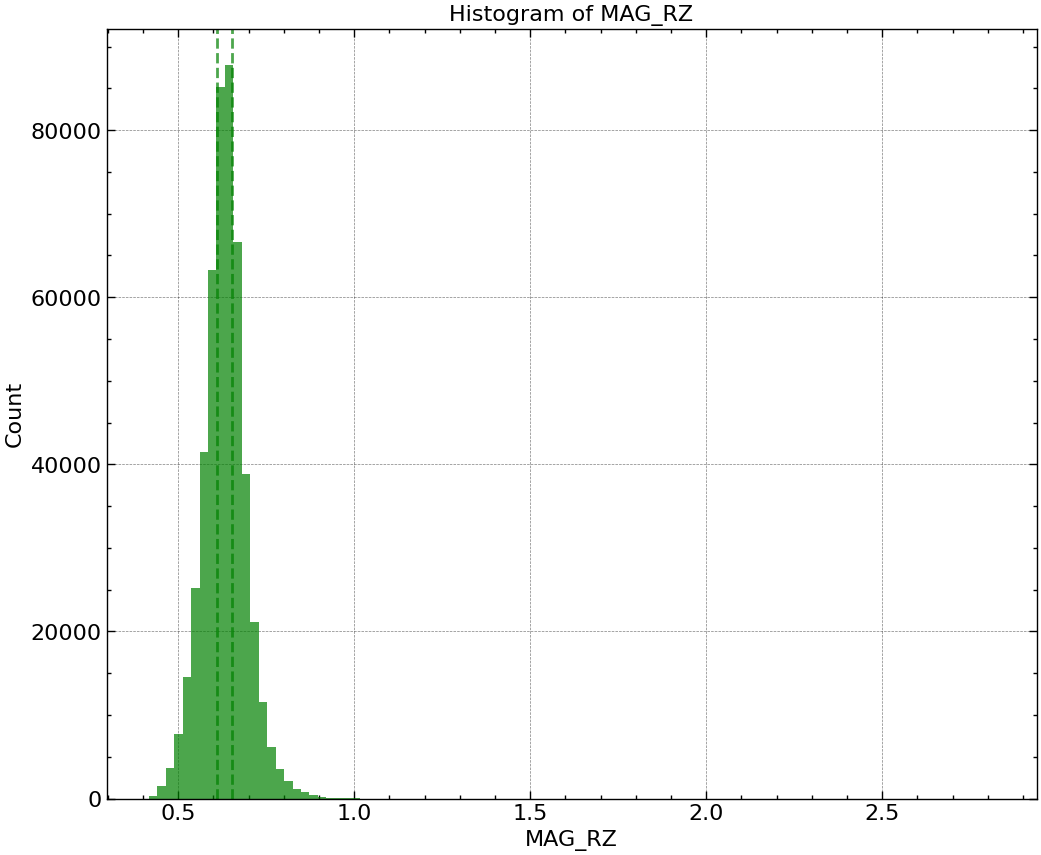

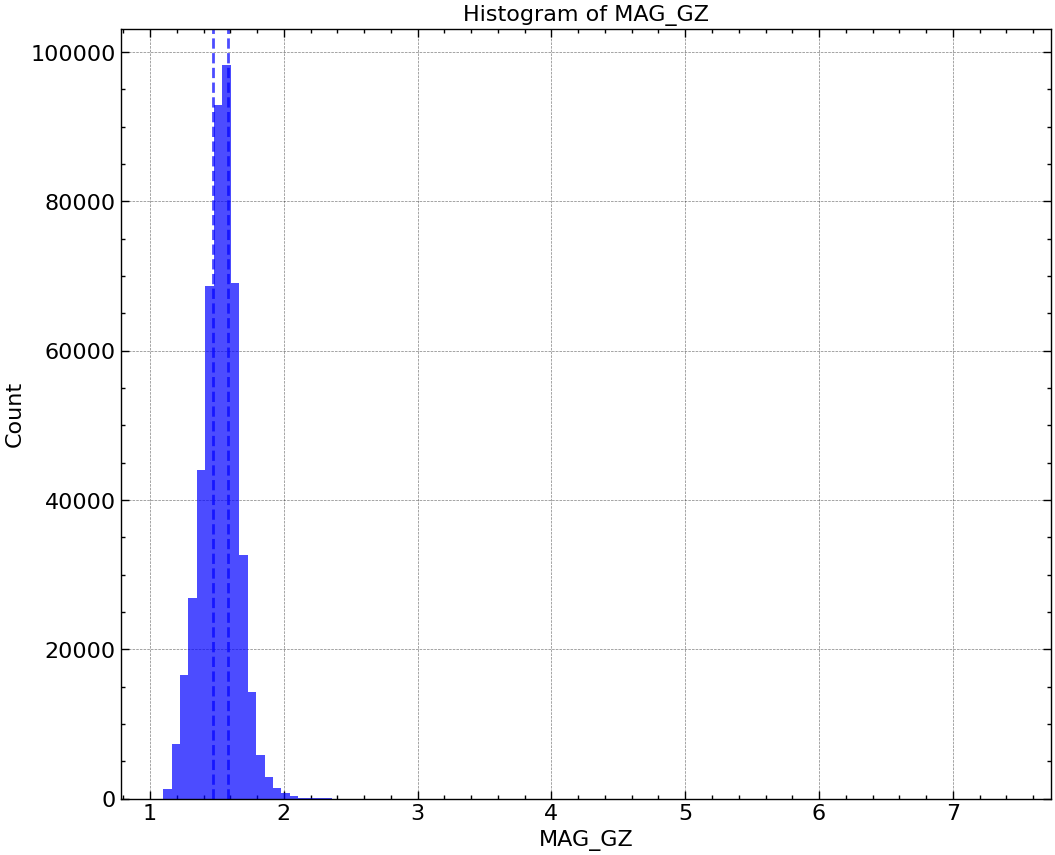

In [103]:
properties = ['MAG_GR','MAG_RZ','MAG_GZ']
bins = 3
colors= {'MAG_GR': 'red', 'MAG_RZ': 'green', 'MAG_GZ': 'blue'}
edges_prop = {}
for part in [ 'full']:
    
    edges_prop[part] = {}
    for property in properties:
        plt.figure(figsize=(12, 10))
        if part == 'full':
            data = table[property]
        elif part == 'north' :
            data = table_north[property]
        else:            
            data = table_south[property]
    
        edges = np.quantile(data, np.linspace(0, 1, bins + 1))
        edges_prop[part][property] = edges
        plt.hist(data, bins=100, alpha=0.7, color=colors[property])
        for edge in range(len(edges)-2):
            plt.axvline(edges[edge+1], color=colors[property], linestyle='--', alpha=0.7)
        plt.xlabel(property)
        plt.ylabel('Count')
        plt.title(f'Histogram of {property}')
        plt.show()

In [104]:
print("MAG_R bins:")
BIN_COL = ['MAG_GR','MAG_RZ','MAG_GZ']
bins_list = {}
_bin_masks  = {}
_bin_tables = {}
for part in ['full']:
    bins_list[part] = {}
    for BIN in BIN_COL:
    #print(f"  {part}: {edges_prop[part][BIN_COL]}")
        bins_to_run = make_bins_full(
            table, RA_all, DEC_all,
            col     = BIN,
            edges   = edges_prop[part][BIN],
            weights = None, mask_store=_bin_masks, table_store=_bin_tables
        )
        bins_list[part][BIN] = bins_to_run


MAG_R bins:
  MAG_GR [0.68, 0.861): 161,077 galaxies
  MAG_GR [0.861, 0.928): 161,074 galaxies
  MAG_GR [0.928, 4.6): 161,080 galaxies
  MAG_RZ [0.417, 0.61): 161,073 galaxies
  MAG_RZ [0.61, 0.654): 161,078 galaxies
  MAG_RZ [0.654, 2.82): 161,080 galaxies
  MAG_GZ [1.1, 1.47): 161,077 galaxies
  MAG_GZ [1.47, 1.58): 161,074 galaxies
  MAG_GZ [1.58, 7.42): 161,080 galaxies


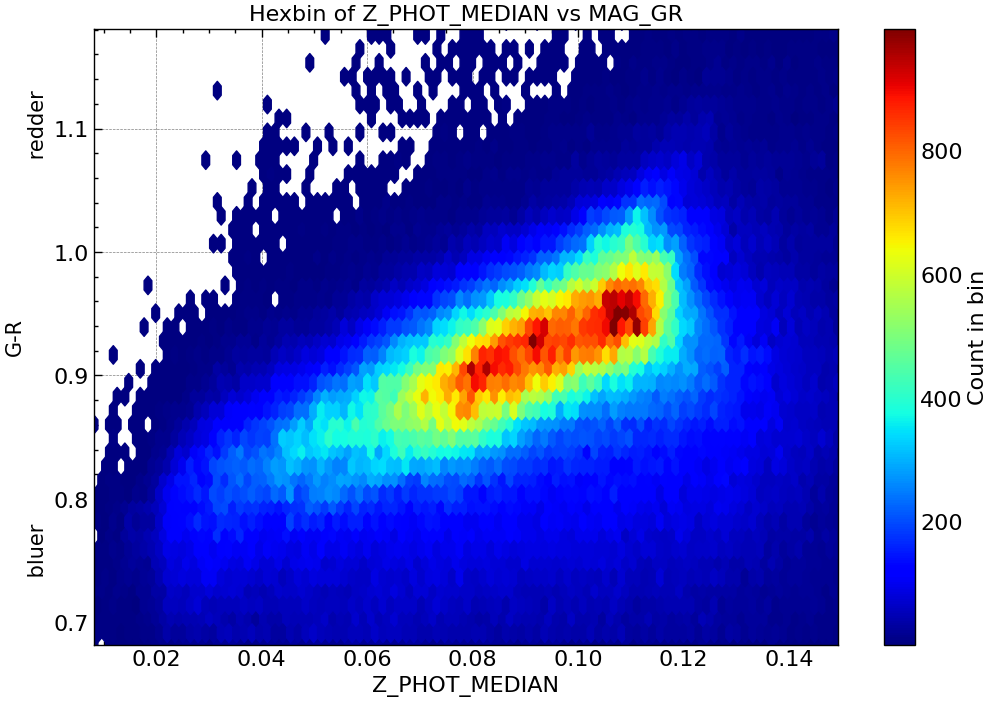

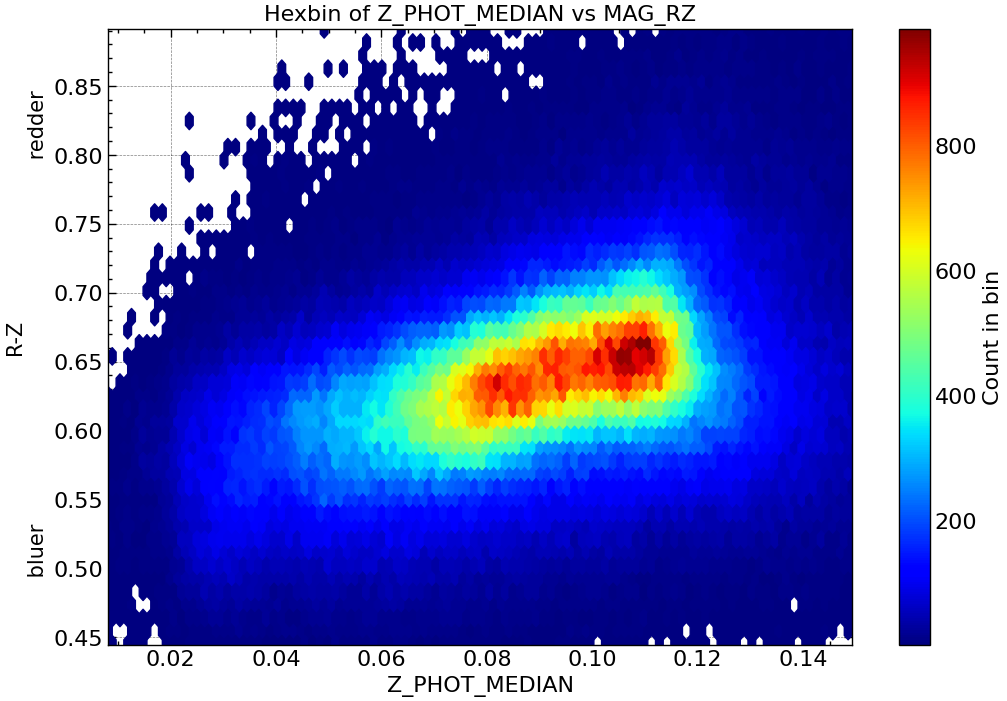

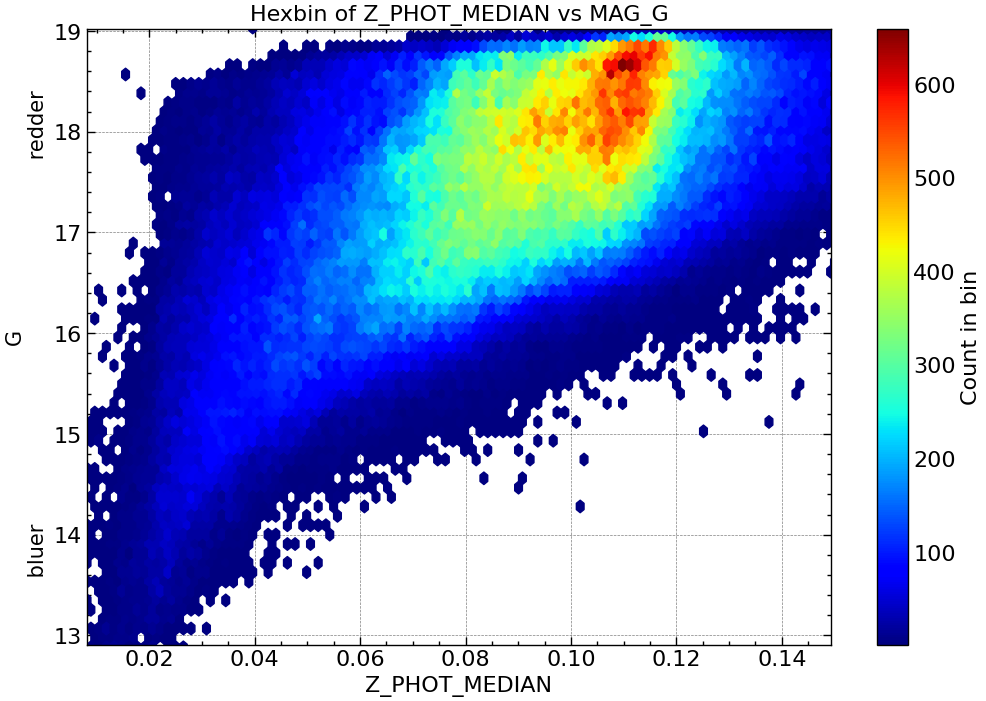

In [105]:
plt.figure(figsize=(12, 8))
plt.hexbin(table['Z_PHOT_MEDIAN'][table['Z_PHOT_MEDIAN']>0],
           table['MAG_GR'][table['Z_PHOT_MEDIAN']>0],
           gridsize=100, cmap='jet', mincnt=1)

plt.xlabel('Z_PHOT_MEDIAN')
plt.ylabel('G-R\n bluer                                                       redder', fontsize=15)
plt.ylim(np.percentile(table['MAG_GR'], [0.1, 99.9]))
plt.xlim(np.percentile(table['Z_PHOT_MEDIAN'], [0.1, 99.9]))
plt.title('Hexbin of Z_PHOT_MEDIAN vs MAG_GR')
cb = plt.colorbar()
cb.set_label('Count in bin')
plt.show()
plt.figure(figsize=(12, 8))
plt.hexbin(table['Z_PHOT_MEDIAN'][table['Z_PHOT_MEDIAN']>0],
           table['MAG_RZ'][table['Z_PHOT_MEDIAN']>0],
           gridsize=100, cmap='jet', mincnt=1)

plt.xlabel('Z_PHOT_MEDIAN')
plt.ylabel('R-Z\n bluer                                                       redder', fontsize=15)
plt.ylim(np.percentile(table['MAG_RZ'], [0.1, 99.9]))
plt.xlim(np.percentile(table['Z_PHOT_MEDIAN'], [0.1, 99.9]))
plt.title('Hexbin of Z_PHOT_MEDIAN vs MAG_RZ')
cb = plt.colorbar()
cb.set_label('Count in bin')
plt.show()


plt.figure(figsize=(12, 8))
plt.hexbin(table['Z_PHOT_MEDIAN'][table['Z_PHOT_MEDIAN']>0],
           table['MAG_G'][table['Z_PHOT_MEDIAN']>0],
           gridsize=100, cmap='jet', mincnt=1)

plt.xlabel('Z_PHOT_MEDIAN')
plt.ylabel('G\n bluer                                                       redder', fontsize=15)
plt.ylim(np.percentile(table['MAG_G'], [0.1, 99.9]))
plt.xlim(np.percentile(table['Z_PHOT_MEDIAN'], [0.1, 99.9]))
plt.title('Hexbin of Z_PHOT_MEDIAN vs MAG_G')
cb = plt.colorbar()
cb.set_label('Count in bin')
plt.show()

In [106]:
results_dict = {}
for part in ['full']:
    results_dict[part] = {}
    
    for BIN in BIN_COL:
        res = run_all_bins(bins_list[part][BIN], parallel=True)
        results_dict[part][BIN] = {lbl: res[lbl] for lbl, *_ in bins_list[part][BIN] if lbl in res}


Running 3 bins  [ERROR=jackknife, weights=True]
  [MAG_GR [0.68, 0.861)]  N=161,077  4.6s
  [MAG_GR [0.928, 4.6)]  N=161,080  4.6s
  [MAG_GR [0.861, 0.928)]  N=161,074  4.7s
All bins done in 4.7s total
Running 3 bins  [ERROR=jackknife, weights=True]
  [MAG_RZ [0.654, 2.82)]  N=161,080  4.3s
  [MAG_RZ [0.61, 0.654)]  N=161,078  4.5s
  [MAG_RZ [0.417, 0.61)]  N=161,073  4.5s
All bins done in 4.5s total
Running 3 bins  [ERROR=jackknife, weights=True]
  [MAG_GZ [1.47, 1.58)]  N=161,074  4.4s
  [MAG_GZ [1.1, 1.47)]  N=161,077  4.4s
  [MAG_GZ [1.58, 7.42)]  N=161,080  4.4s
All bins done in 4.4s total


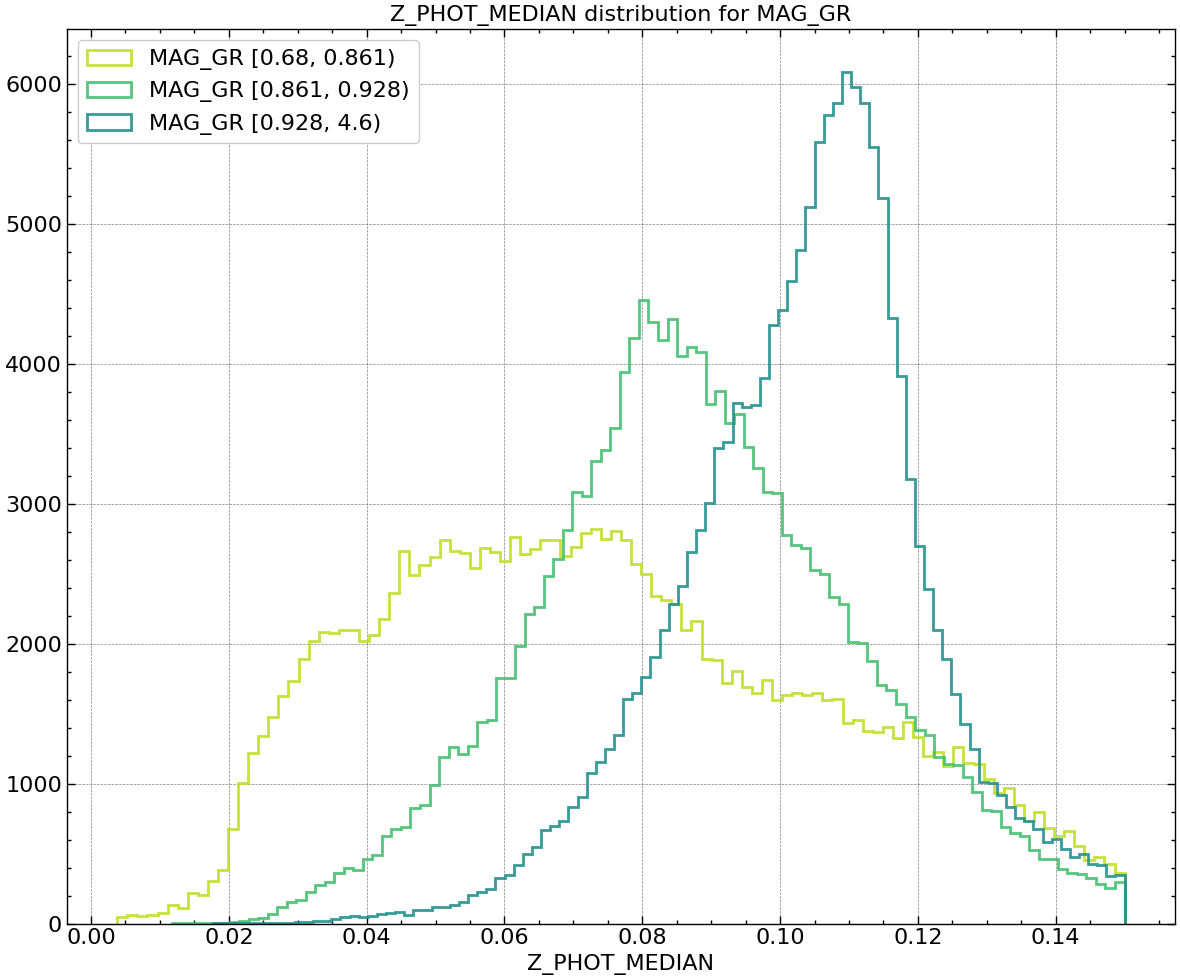

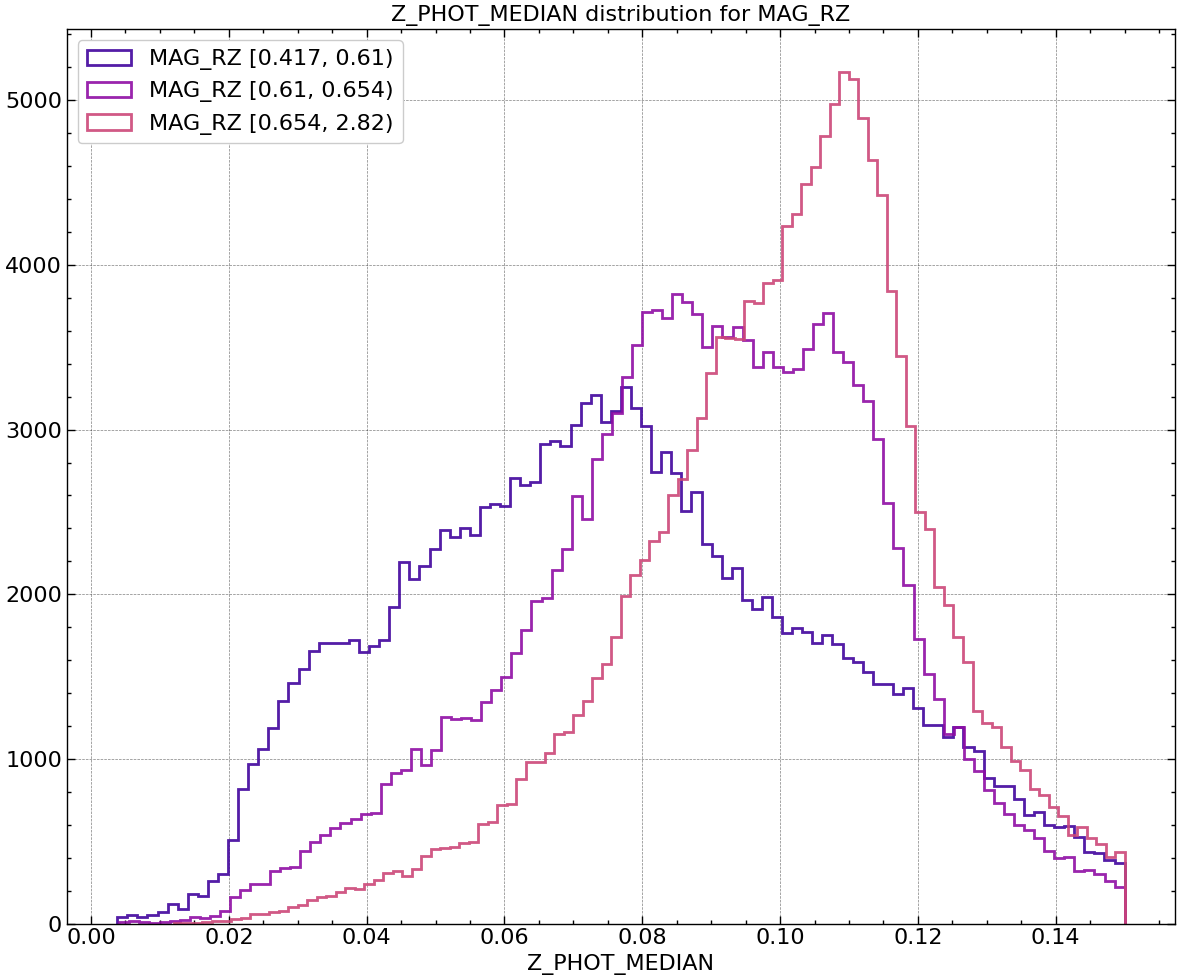

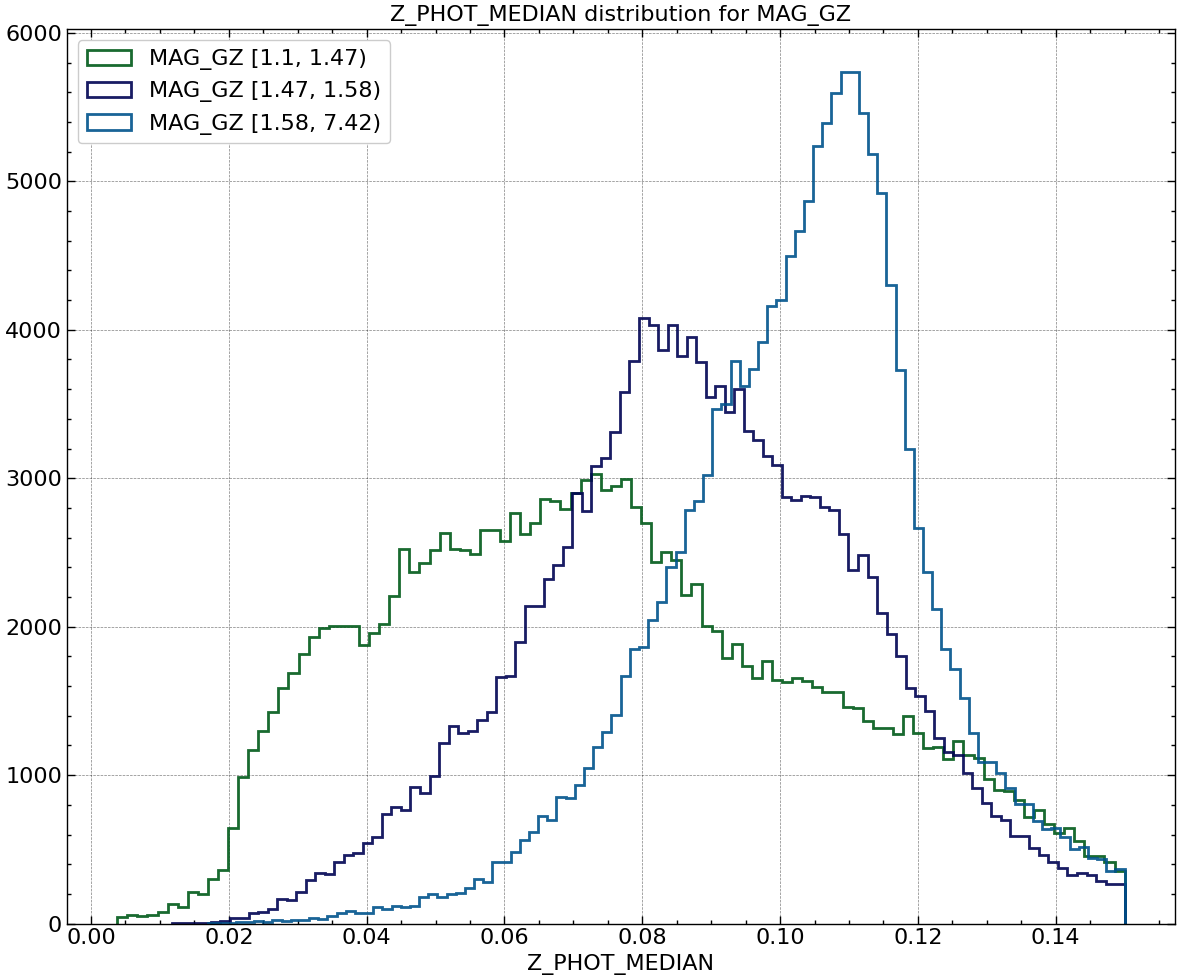

In [107]:
prop_colors = {
    'MAG_GR':  plt.cm.viridis_r(np.linspace(0.1, 0.9, 5)),
    'MAG_RZ': plt.cm.plasma(np.linspace(0.1, 0.9, 5)),
    'MAG_GZ': plt.cm.ocean(np.linspace(0.1, 1, 5)),
}

for prop, color in prop_colors.items():
    plt.figure(figsize=(12, 10))
    i =0 
    for key_i, mask in _bin_masks.items():
        if prop in key_i:
            z = table[mask]['Z_PHOT_MEDIAN']
            z = z[z > 0]
            
            plt.hist(z, bins=100, color=color[i], alpha=0.9, label=key_i,histtype='step',lw = 2)
            i+=1

    plt.xlabel('Z_PHOT_MEDIAN')
    plt.title(f'Z_PHOT_MEDIAN distribution for {prop}')
    plt.legend()
    plt.tight_layout()
    plt.show()


MAG_GR [0.68, 0.861): N=161,077
MAG_GR [0.861, 0.928): N=161,074
MAG_GR [0.928, 4.6): N=161,080


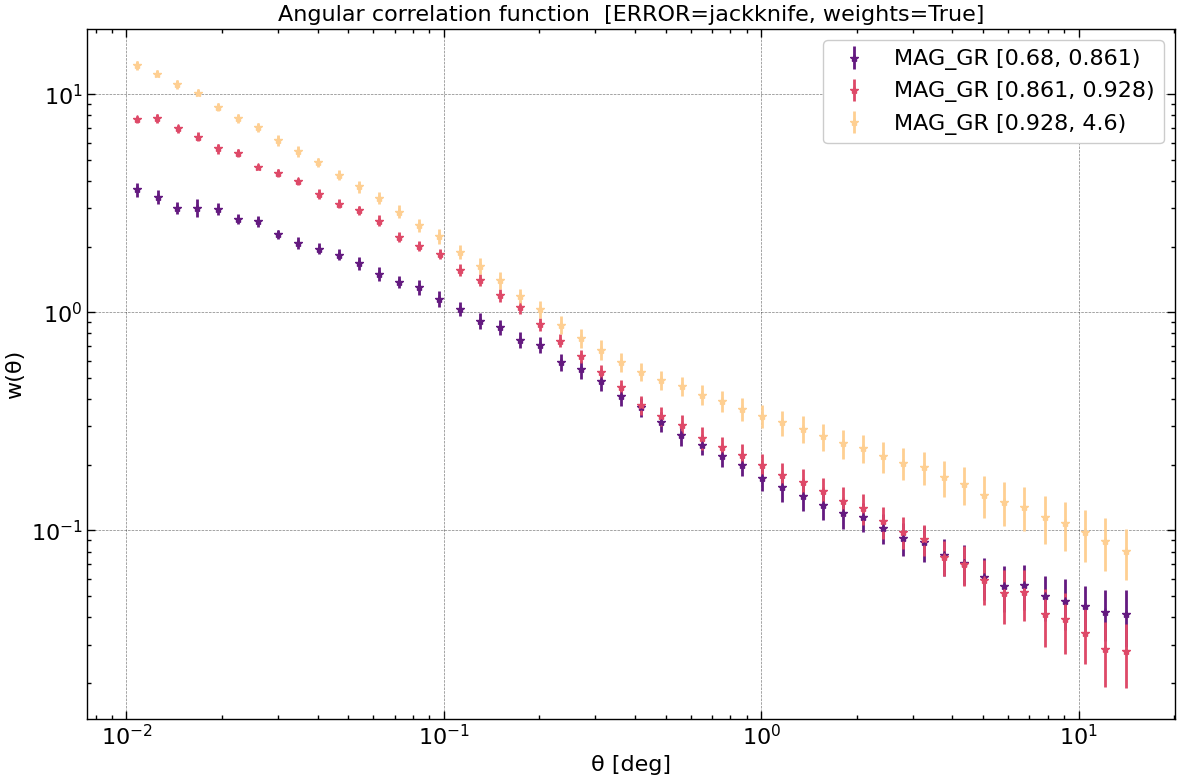

MAG_RZ [0.417, 0.61): N=161,073
MAG_RZ [0.61, 0.654): N=161,078
MAG_RZ [0.654, 2.82): N=161,080


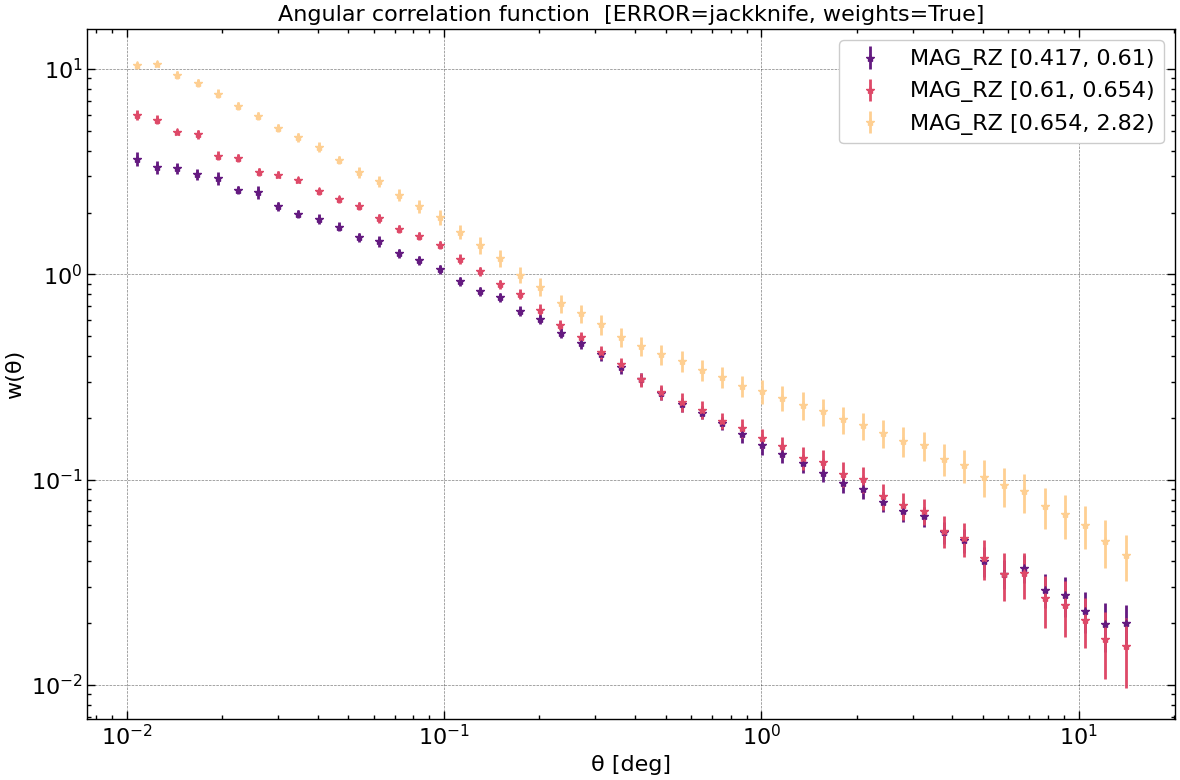

MAG_GZ [1.1, 1.47): N=161,077
MAG_GZ [1.47, 1.58): N=161,074
MAG_GZ [1.58, 7.42): N=161,080


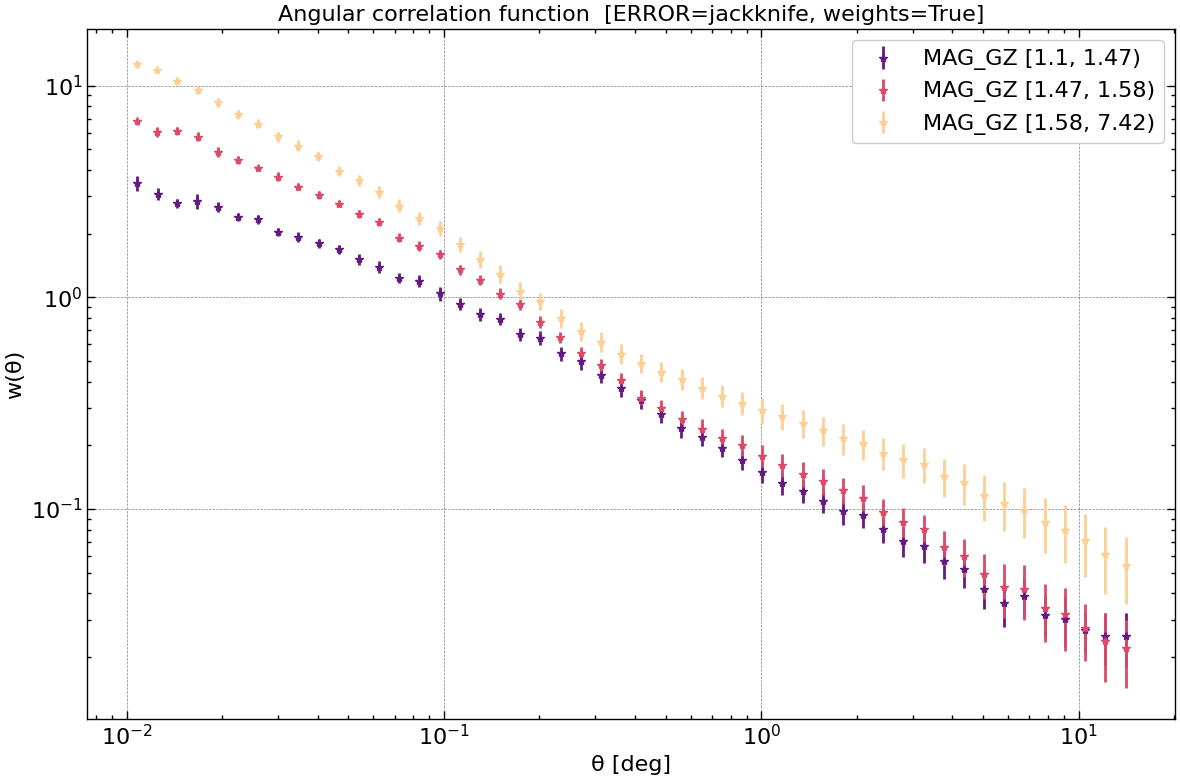

In [108]:
colors = plt.cm.magma(np.linspace(0.3, 0.9, len(results_dict['full']['MAG_GR'])))
for result in results_dict['full']:
    plt.figure(figsize=(12, 8))
    for bin_label in results_dict['full'][result]:
        print(f"{bin_label}: N={results_dict['full'][result][bin_label]['n']:,}")
        plt.errorbar(results_dict['full'][result][bin_label]['meanr'], 
                     results_dict['full'][result][bin_label]['xi'], 
                     yerr=results_dict['full'][result][bin_label]['sig'],
                     fmt='*-', label=bin_label, ls='None', color=colors[list(results_dict['full'][result]).index(bin_label)])

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('θ [deg]')
    plt.ylabel('w(θ)')
    plt.title(f"Angular correlation function  [ERROR={ERROR}, weights={USE_WEIGHTS}]")
    plt.legend()
    plt.tight_layout()
    plt.show()

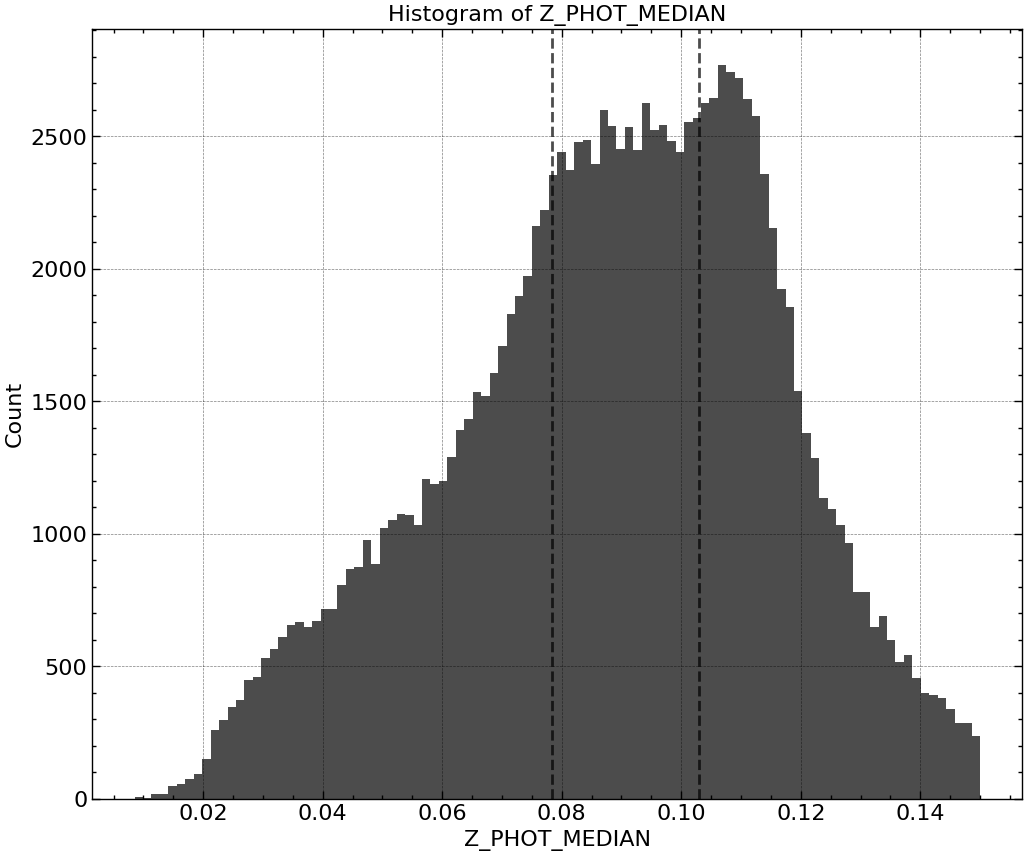

In [146]:
properties = ['Z_PHOT_MEDIAN']
bins = 3
colors= {'MAG_GR': 'red', 'MAG_RZ': 'green', 'MAG_GZ': 'blue'}
edges_prop = {}
for part in [ 'full']:
    
    edges_prop[part] = {}
    for property in properties:
        plt.figure(figsize=(12, 10))
        if part == 'full':
            data = table[property]
        elif part == 'north' :
            data = table_north[property]
        else:            
            data = table_south[property]
        data = data[data > 0]
        edges = np.quantile(data, np.linspace(0, 1, bins + 1))
        edges_prop[part][property] = edges
        plt.hist(data, bins=100, alpha=0.7, color='k')
        for edge in range(len(edges)-2):
            plt.axvline(edges[edge+1], color='k', linestyle='--', alpha=0.7)
        plt.xlabel(property)
        plt.ylabel('Count')
        plt.title(f'Histogram of {property}')
        plt.show()

In [151]:

BIN_COL = ['Z_PHOT_MEDIAN']
bins_list = {}
_bin_masks  = {}
_bin_tables = {}
for part in ['full']:
    bins_list[part] = {}
    for BIN in BIN_COL:
    #print(f"  {part}: {edges_prop[part][BIN_COL]}")
        bins_to_run = make_bins_full(
            table, RA_all, DEC_all,
            col     = BIN,
            edges   = edges_prop[part][BIN],
            weights = None,mask_store=_bin_masks, table_store=_bin_tables
        )
        bins_list[part][BIN] = bins_to_run

  Z_PHOT_MEDIAN [0.00852, 0.0784): 162,618 galaxies
  Z_PHOT_MEDIAN [0.0784, 0.103): 157,209 galaxies
  Z_PHOT_MEDIAN [0.103, 0.15): 162,904 galaxies


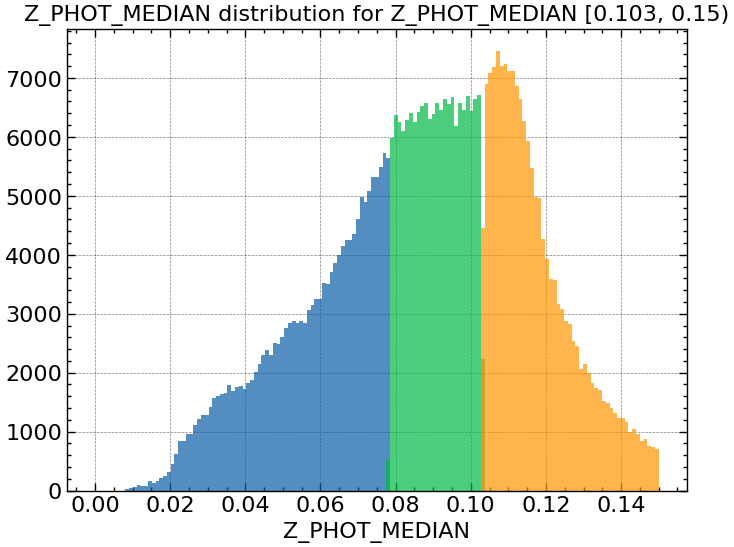

In [152]:
bins = np.linspace(0,0.15,150)
for table in _bin_tables:
    plt.hist(_bin_tables[table]['Z_PHOT_MEDIAN'], bins=bins, alpha=0.7)
    plt.xlabel('Z_PHOT_MEDIAN')
    plt.title(f'Z_PHOT_MEDIAN distribution for {table}')
    #plt.show()

In [153]:
results_dict = {}
for part in ['full']:
    results_dict[part] = {}
    
    for BIN in BIN_COL:
        res = run_all_bins(bins_list[part][BIN], parallel=True)
        results_dict[part][BIN] = {lbl: res[lbl] for lbl, *_ in bins_list[part][BIN] if lbl in res}


Running 3 bins  [ERROR=jackknife, weights=True]
  [Z_PHOT_MEDIAN [0.00852, 0.0784)]  N=162,618  4.7s
  [Z_PHOT_MEDIAN [0.103, 0.15)]  N=162,904  4.7s
  [Z_PHOT_MEDIAN [0.0784, 0.103)]  N=157,209  4.7s
All bins done in 4.8s total


In [157]:
results_dict['full']['Z_PHOT_MEDIAN'].keys()

dict_keys(['Z_PHOT_MEDIAN [0.00852, 0.0784)', 'Z_PHOT_MEDIAN [0.0784, 0.103)', 'Z_PHOT_MEDIAN [0.103, 0.15)'])

In [158]:
upper_scale=15
lower_scale=0.9
mask_fit = (results_dict['full']['Z_PHOT_MEDIAN']['Z_PHOT_MEDIAN [0.00852, 0.0784)']['meanr'] < upper_scale) & \
           (results_dict['full']['Z_PHOT_MEDIAN']['Z_PHOT_MEDIAN [0.00852, 0.0784)']['meanr'] > lower_scale)

Z_PHOT_MEDIAN [0.00852, 0.0784): N=162,618
  Fit bias: 2.220 ± 0.038
Z_PHOT_MEDIAN [0.0784, 0.103): N=157,209
  Fit bias: 2.519 ± 0.042
Z_PHOT_MEDIAN [0.103, 0.15): N=162,904
  Fit bias: 1.760 ± 0.038


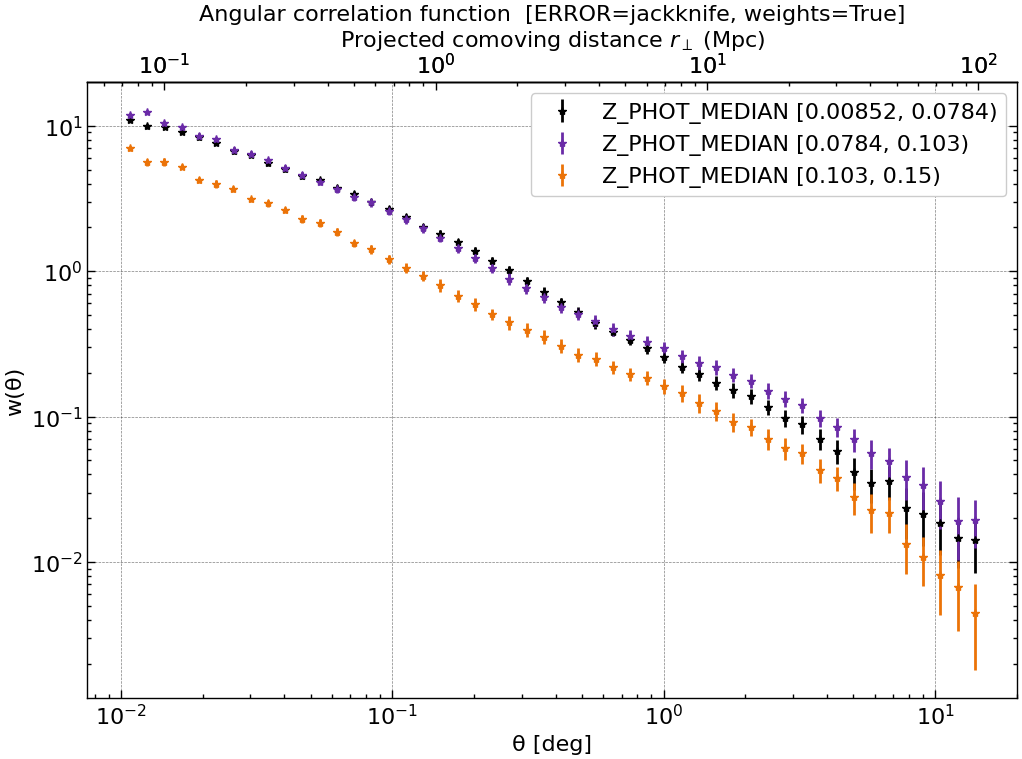

In [163]:
colors = plt.cm.CMRmap(np.linspace(0, 0.6, len(results_dict['full']['Z_PHOT_MEDIAN'])))
for result in results_dict['full']:
    fig, ax = plt.subplots(figsize=(12,8))
    for bin_label in results_dict['full'][result]:
        print(f"{bin_label}: N={results_dict['full'][result][bin_label]['n']:,}")
        popt,pcov = curve_fit(w_theta_func, results_dict['full'][result][bin_label]['meanr'][mask_fit], 
                               results_dict['full'][result][bin_label]['xi'][mask_fit], 
                               sigma=results_dict['full'][result][bin_label]['sig'][mask_fit], 
                               p0=[1.0], absolute_sigma=True)
        print(f"  Fit bias: {popt[0]:.3f} ± {np.sqrt(pcov[0,0]):.3f}")
        ax.errorbar(results_dict['full'][result][bin_label]['meanr'], 
                     results_dict['full'][result][bin_label]['xi'], 
                     yerr=results_dict['full'][result][bin_label]['sig'],
                     fmt='*-', label=bin_label, ls='None', color=colors[list(results_dict['full'][result]).index(bin_label)])

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('θ [deg]')
    ax.set_ylabel('w(θ)')
    ax.set_title(f"Angular correlation function  [ERROR={ERROR}, weights={USE_WEIGHTS}]")
    ax.legend()
    secax = ax.secondary_xaxis('top',
    functions=(theta_to_r_dc,r_to_theta_dc))
    secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
    secax = ax.secondary_xaxis('top', functions=(theta_to_r_dc, r_to_theta_dc))
    secax.tick_params(axis='x', which='both', length=0)  # removes the tick marks, keeps labels
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)



In [109]:
south_index_FP_spec, south_index_DR1, south_z_use, south_z_source = [np.load('/user/animesh.sah/DESI_PECVEL/ML_photoz/redshift_south.npz')[key] for key in ['index_FP_spec', 'index_DR1', 'z_use', 'z_source']]
north_index_FP_spec, north_index_DR1, north_z_use, north_z_source = [np.load('/user/animesh.sah/DESI_PECVEL/ML_photoz/redshift_north.npz')[key] for key in ['index_FP_spec', 'index_DR1', 'z_use', 'z_source']]


In [110]:
len(north_z_use), len(south_z_use), len(table_north), len(table_south)

(141740, 330821, 141740, 330821)

In [164]:
from astropy.table import vstack

table_full = vstack([table_north, table_south], join_type='exact', metadata_conflicts='silent')



z_use = vstack([north_z_use, south_z_use])
z_use=z_use['col0']
z_source = vstack([north_z_source, south_z_source])
z_source = z_source['col0']
table_full['Z_SOURCE'] = z_source
table_full['Z_USE'] = z_use

In [ ]:
#plt.hist(table_full['Z_PHOT_MEDIAN'][np.isfinite(np.array(z_use))]-z_use[np.isfinite(np.array(z_use))], alpha=0.5)


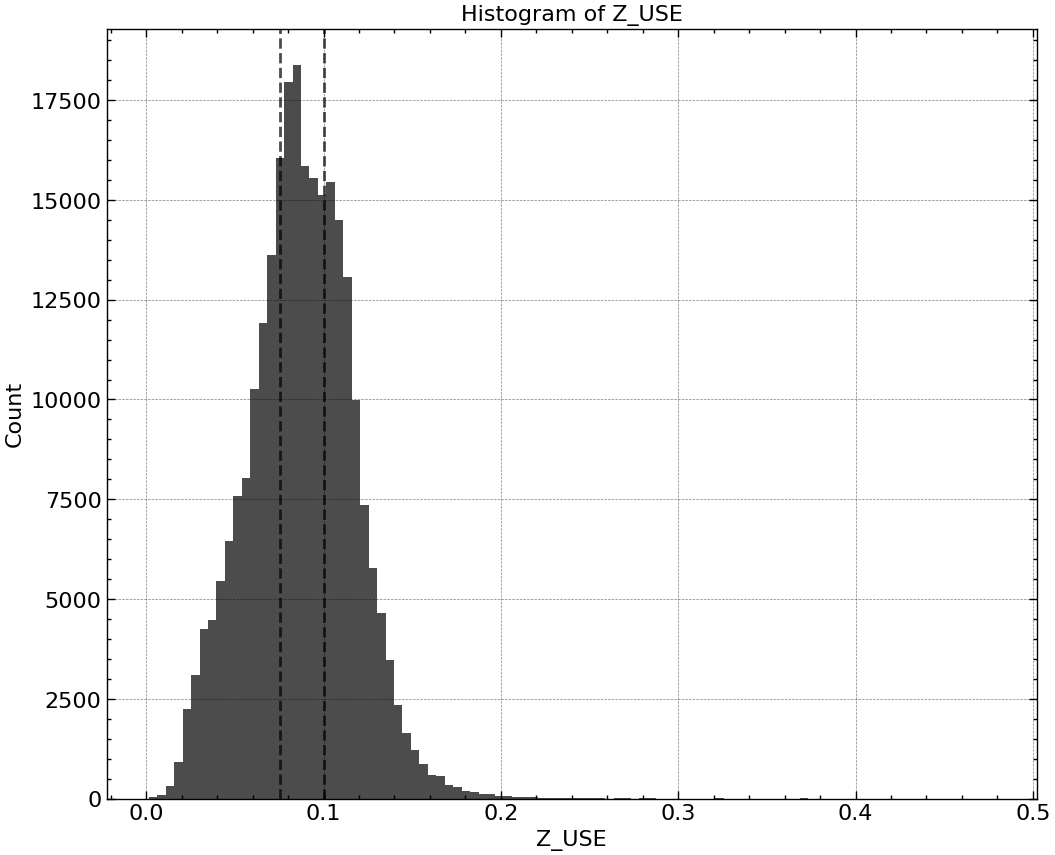

In [165]:
properties = ['Z_USE']
bins = 3
edges_prop = {}
for part in [ 'full']:
    
    edges_prop[part] = {}
    table = table_full[table_full['Z_USE'] > 0]
    for property in properties:
        plt.figure(figsize=(12, 10))
        if part == 'full':
            data = table[property]
        elif part == 'north' :
            data = table_north[property]
        else:            
            data = table_south[property]
        data = data[data > 0]
        edges = np.quantile(data, np.linspace(0, 1, bins + 1))
        edges_prop[part][property] = edges
        plt.hist(data, bins=100, alpha=0.7, color='k')
        for edge in range(len(edges)-2):
            plt.axvline(edges[edge+1], color='k', linestyle='--', alpha=0.7)
        plt.xlabel(property)
        plt.ylabel('Count')
        plt.title(f'Histogram of {property}')
        plt.show()

In [166]:

BIN_COL = ['Z_USE']
bins_list = {}
_bin_masks  = {}
_bin_tables = {}
for part in ['full']:
    bins_list[part] = {}
    for BIN in BIN_COL:
        bins_to_run = make_bins_full(
            table, table['RA'], table['DEC'],
            col     = BIN,
            edges   = edges_prop[part][BIN],
            weights = None,mask_store=_bin_masks, table_store=_bin_tables
        )
        bins_list[part][BIN] = bins_to_run

  Z_USE [0.00144, 0.0755): 86,914 galaxies
  Z_USE [0.0755, 0.1): 86,914 galaxies
  Z_USE [0.1, 0.478): 86,913 galaxies


In [167]:
results_dict = {}
for part in ['full']:
    results_dict[part] = {}
    
    for BIN in BIN_COL:
        res = run_all_bins(bins_list[part][BIN], parallel=True)
        results_dict[part][BIN] = {lbl: res[lbl] for lbl, *_ in bins_list[part][BIN] if lbl in res}


Running 3 bins  [ERROR=jackknife, weights=True]
  [Z_USE [0.00144, 0.0755)]  N=86,914  4.0s
  [Z_USE [0.1, 0.478)]  N=86,913  4.0s
  [Z_USE [0.0755, 0.1)]  N=86,914  4.0s
All bins done in 4.0s total


In [168]:
upper_scale=15
lower_scale=0.9
mask_fit = (results_dict['full']['Z_USE']['Z_USE [0.00144, 0.0755)']['meanr'] < upper_scale) & \
           (results_dict['full']['Z_USE']['Z_USE [0.00144, 0.0755)']['meanr'] > lower_scale)

Z_USE [0.00144, 0.0755): N=86,914
  Fit bias: 4.503 ± 0.079
Z_USE [0.0755, 0.1): N=86,914
  Fit bias: 4.954 ± 0.101
Z_USE [0.1, 0.478): N=86,913
  Fit bias: 4.008 ± 0.076


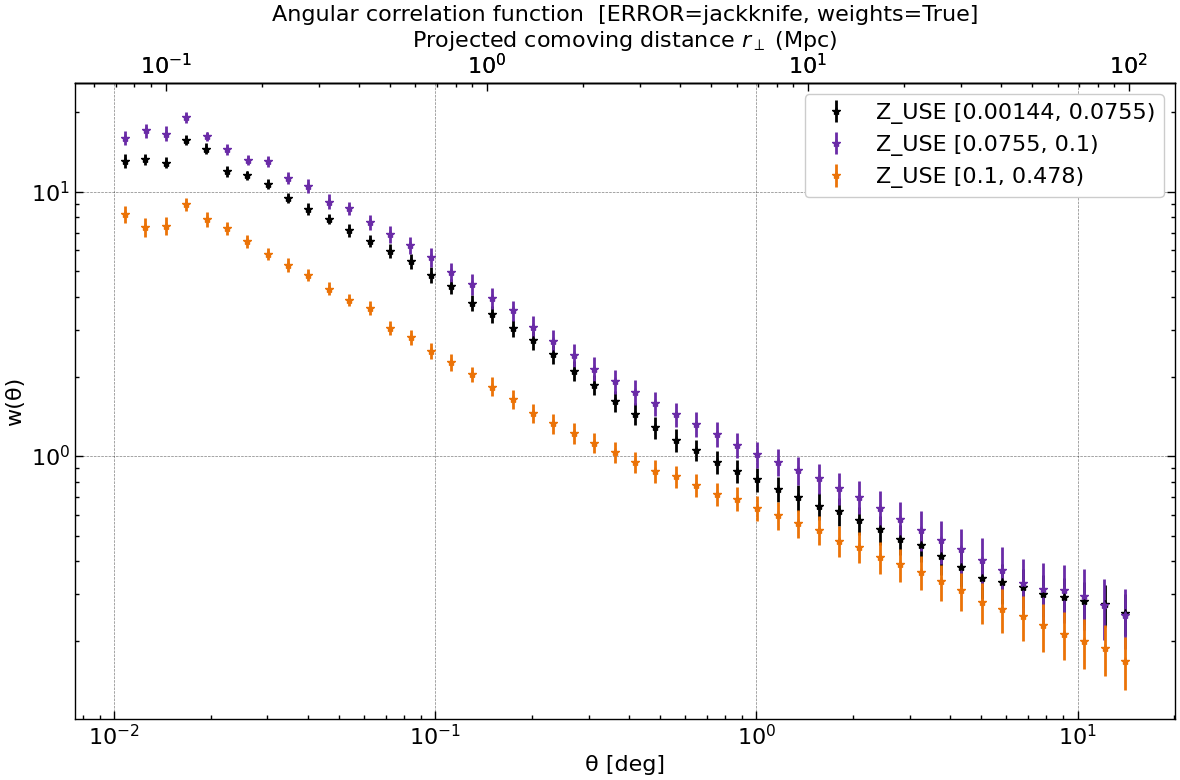

In [169]:
colors = plt.cm.CMRmap(np.linspace(0, 0.6, len(results_dict['full']['Z_USE'])))
for result in results_dict['full']:
    fig,ax = plt.subplots(figsize=(12, 8))
    for bin_label in results_dict['full'][result]:
        print(f"{bin_label}: N={results_dict['full'][result][bin_label]['n']:,}")
        popt,pcov = curve_fit(w_theta_func, results_dict['full'][result][bin_label]['meanr'][mask_fit], 
                               results_dict['full'][result][bin_label]['xi'][mask_fit], 
                               sigma=results_dict['full'][result][bin_label]['sig'][mask_fit], 
                               p0=[1.0], absolute_sigma=True)
        print(f"  Fit bias: {popt[0]:.3f} ± {np.sqrt(pcov[0,0]):.3f}")
        ax.errorbar(results_dict['full'][result][bin_label]['meanr'], 
                     results_dict['full'][result][bin_label]['xi'], 
                     yerr=results_dict['full'][result][bin_label]['sig'],
                     fmt='*-', label=bin_label, ls='None', color=colors[list(results_dict['full'][result]).index(bin_label)])

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('θ [deg]')
    ax.set_ylabel('w(θ)')
    ax.set_title(f"Angular correlation function  [ERROR={ERROR}, weights={USE_WEIGHTS}]")
    ax.legend()
    secax = ax.secondary_xaxis('top',
    functions=(theta_to_r_dc,r_to_theta_dc))
    secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
    secax = ax.secondary_xaxis('top', functions=(theta_to_r_dc, r_to_theta_dc))
    secax.tick_params(axis='x', which='both', length=0)  # removes the tick marks, keeps labels
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)




    plt.tight_layout()
    plt.show()

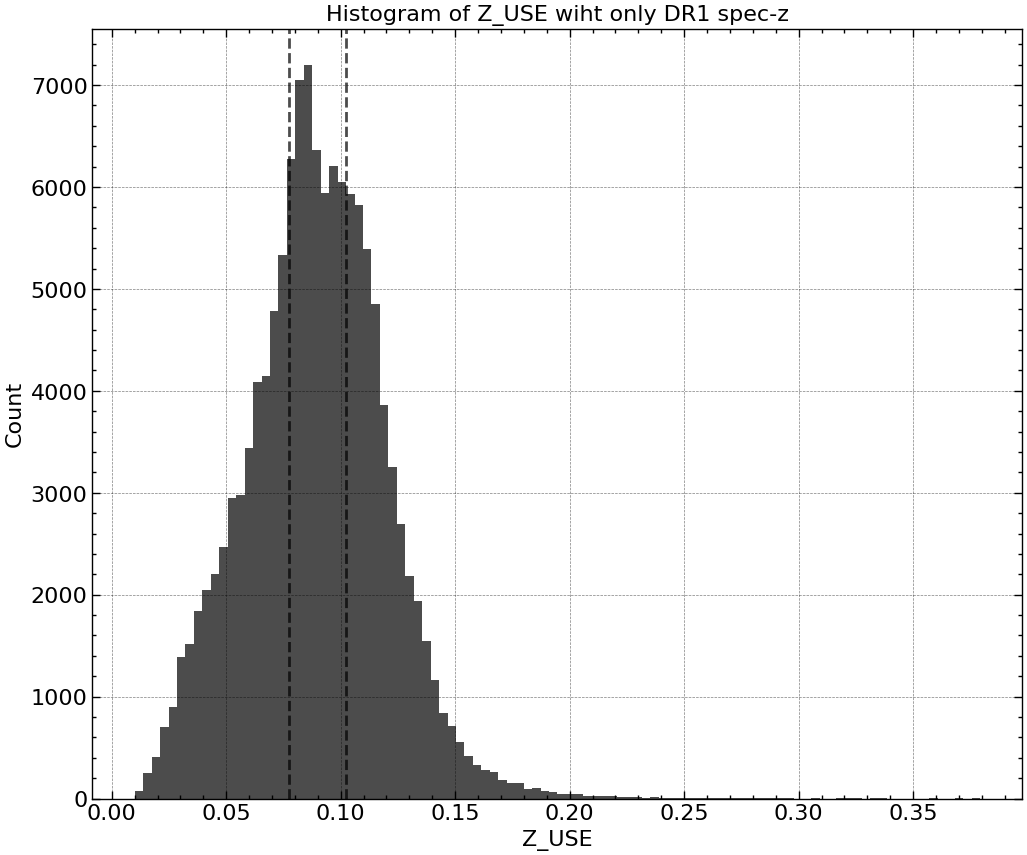

In [170]:
properties = ['Z_USE']
bins = 3
edges_prop = {}
for part in [ 'full']:
    
    edges_prop[part] = {}
    table = table_full[table_full['Z_SOURCE'] =='DR1']
    for property in properties:
        plt.figure(figsize=(12, 10))
        if part == 'full':
            data = table[property]
        elif part == 'north' :
            data = table_north[property]
        else:            
            data = table_south[property]
        data = data[data > 0]
        edges = np.quantile(data, np.linspace(0, 1, bins + 1))
        edges_prop[part][property] = edges
        plt.hist(data, bins=100, alpha=0.7, color='k')
        for edge in range(len(edges)-2):
            plt.axvline(edges[edge+1], color='k', linestyle='--', alpha=0.7)
        plt.xlabel(property)
        plt.ylabel('Count')
        plt.title(f'Histogram of {property} wiht only DR1 spec-z')
        plt.show()

In [171]:

BIN_COL = ['Z_USE']
bins_list = {}
_bin_masks  = {}
_bin_tables = {}
for part in ['full']:
    bins_list[part] = {}
    for BIN in BIN_COL:
        bins_to_run = make_bins_full(
            table, table['RA'], table['DEC'],
            col     = BIN,
            edges   = edges_prop[part][BIN],
            weights = None,mask_store=_bin_masks, table_store=_bin_tables
        )
        bins_list[part][BIN] = bins_to_run

  Z_USE [0.01, 0.0776): 43,275 galaxies
  Z_USE [0.0776, 0.102): 43,275 galaxies
  Z_USE [0.102, 0.379): 43,275 galaxies


In [172]:
results_dict = {}
for part in ['full']:
    results_dict[part] = {}
    
    for BIN in BIN_COL:
        res = run_all_bins(bins_list[part][BIN], parallel=True)
        results_dict[part][BIN] = {lbl: res[lbl] for lbl, *_ in bins_list[part][BIN] if lbl in res}


Running 3 bins  [ERROR=jackknife, weights=True]
  [Z_USE [0.0776, 0.102)]  N=43,275  3.0s
  [Z_USE [0.102, 0.379)]  N=43,275  3.3s
  [Z_USE [0.01, 0.0776)]  N=43,275  3.4s
All bins done in 3.4s total


In [175]:
upper_scale=15
lower_scale=0.9
mask_fit = (results_dict['full']['Z_USE']['Z_USE [0.0776, 0.102)']['meanr'] < upper_scale) & \
           (results_dict['full']['Z_USE']['Z_USE [0.0776, 0.102)']['meanr'] > lower_scale)

Z_USE [0.01, 0.0776): N=43,275
  Fit bias: 5.538 ± 0.110
Z_USE [0.0776, 0.102): N=43,275
  Fit bias: 6.392 ± 0.118
Z_USE [0.102, 0.379): N=43,275
  Fit bias: 5.523 ± 0.082


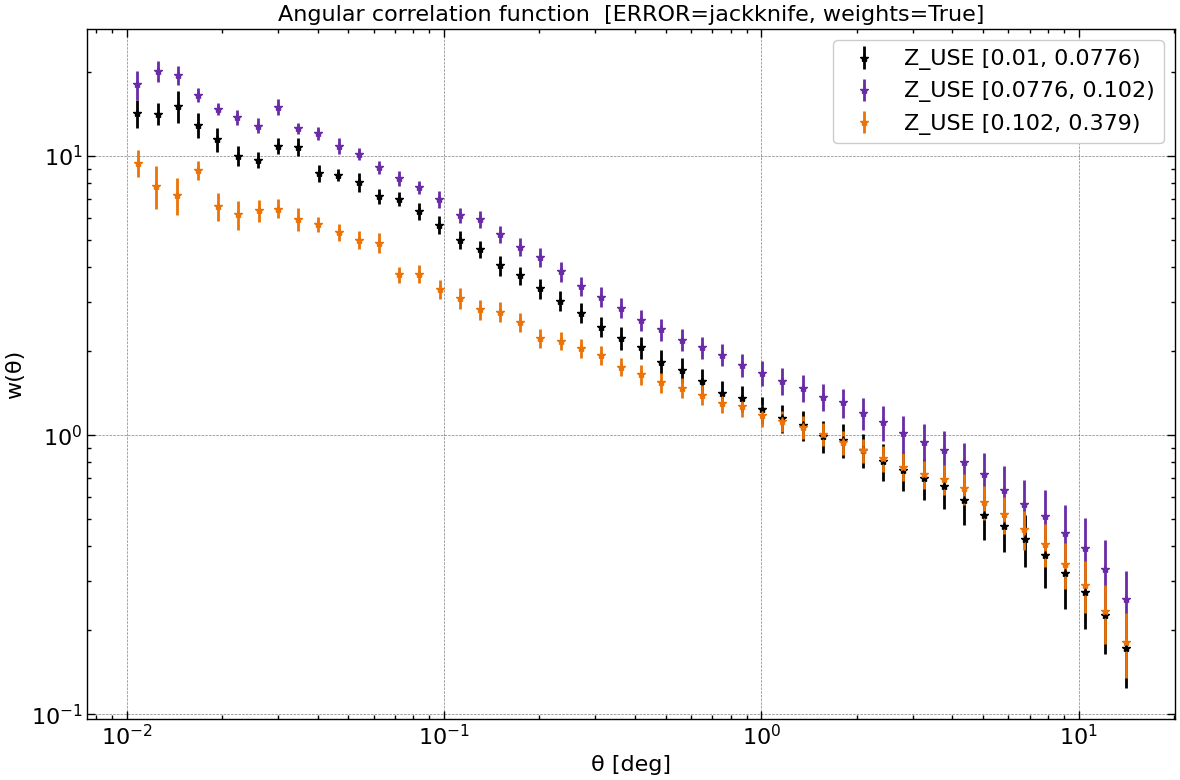

In [177]:
colors = plt.cm.CMRmap(np.linspace(0, 0.6, len(results_dict['full']['Z_USE'])))
for result in results_dict['full']:
    fig,ax = plt.subplots(figsize=(12, 8))
    for bin_label in results_dict['full'][result]:
        print(f"{bin_label}: N={results_dict['full'][result][bin_label]['n']:,}")
        popt,pcov = curve_fit(w_theta_func, results_dict['full'][result][bin_label]['meanr'][mask_fit], 
                               results_dict['full'][result][bin_label]['xi'][mask_fit], 
                               sigma=results_dict['full'][result][bin_label]['sig'][mask_fit], 
                               p0=[1.0], absolute_sigma=True)
        print(f"  Fit bias: {popt[0]:.3f} ± {np.sqrt(pcov[0,0]):.3f}")
        ax.errorbar(results_dict['full'][result][bin_label]['meanr'], 
                     results_dict['full'][result][bin_label]['xi'], 
                     yerr=results_dict['full'][result][bin_label]['sig'],
                     fmt='*-', label=bin_label, ls='None', color=colors[list(results_dict['full'][result]).index(bin_label)])

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('θ [deg]')
    ax.set_ylabel('w(θ)')
    ax.set_title(f"Angular correlation function  [ERROR={ERROR}, weights={USE_WEIGHTS}]")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# ── Save results ──────────────────────────────────────────────────────────────
for lbl, res in results.items():
    safe = (lbl.replace(' ', '_').replace('[', '').replace(']', '')
               .replace(',', '-').replace(')', '').replace('/', 'over'))
    base = os.path.join(OUT_DIR, f'wtheta_{PART}_{safe}_err-{ERROR}_wgt-{USE_WEIGHTS}')
    np.save(base + '.npy', np.vstack([res['meanr'], res['xi'], res['sig']]))
    if res['cov'] is not None:
        np.save(base + '_cov.npy', res['cov'])
    print(f"Saved: {base}.npy")